# Import functions

In [1]:
%run "../Model/DataHelpers.ipynb"

In [2]:
import os
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
from matplotlib.colors import to_hex
import numpy as np
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import auc
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.gridspec import GridSpec

# Run Evaluation for all feature selections

1/21 - FeatureSet literature - SMOTE - Start


------------ Cross-Validation Results


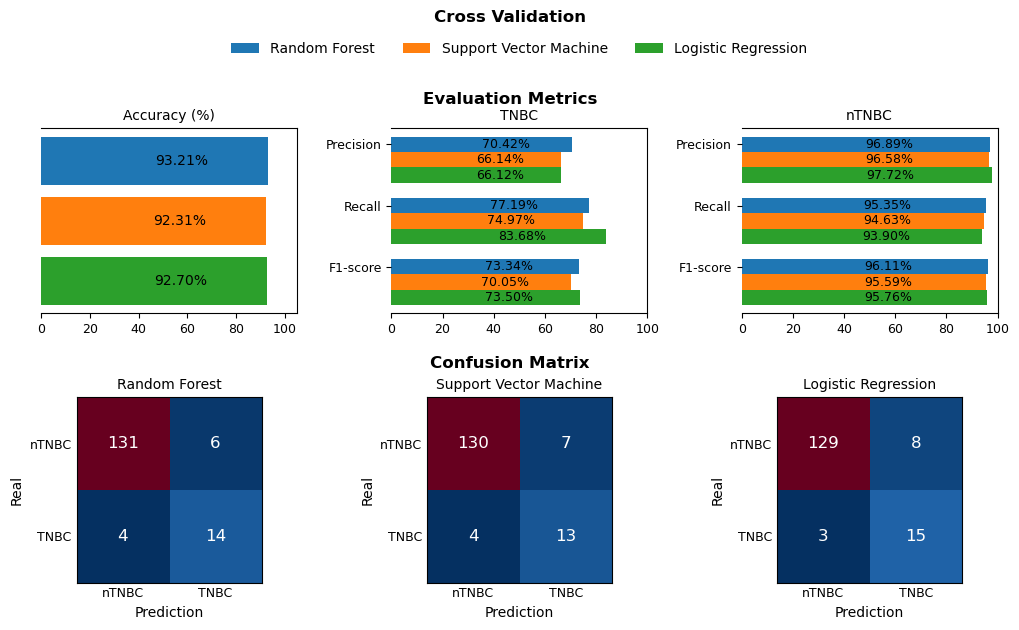



------------ Model Performance Results


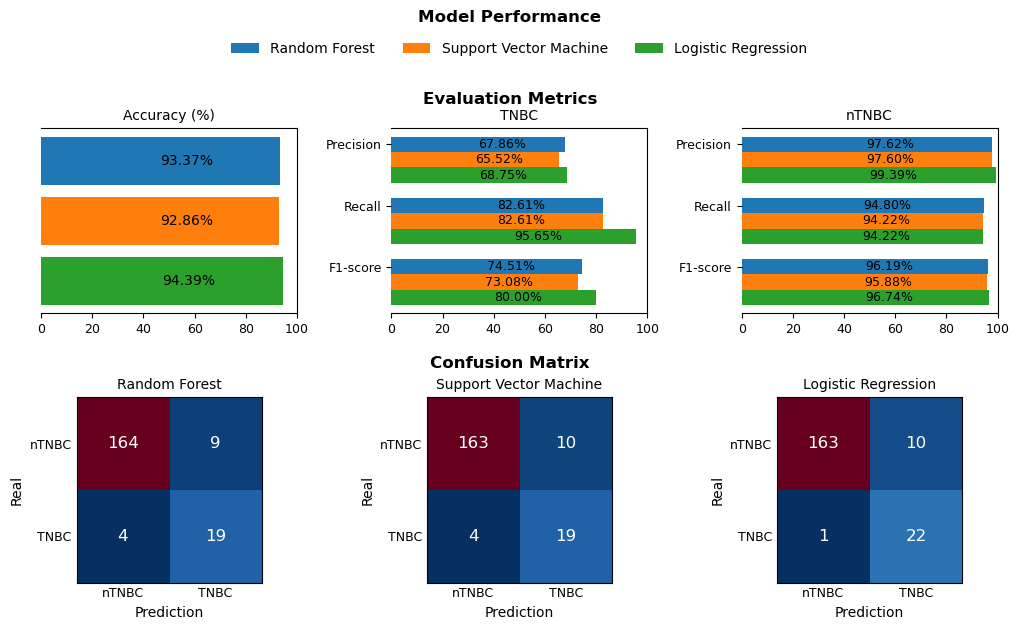



------------ ROC & AUC


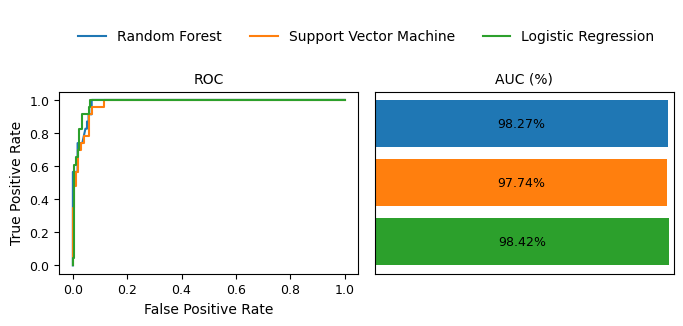

1/21 - FeatureSet literature - SMOTE - End
2/21 - FeatureSet literature - nSMOTE - Start


------------ Cross-Validation Results


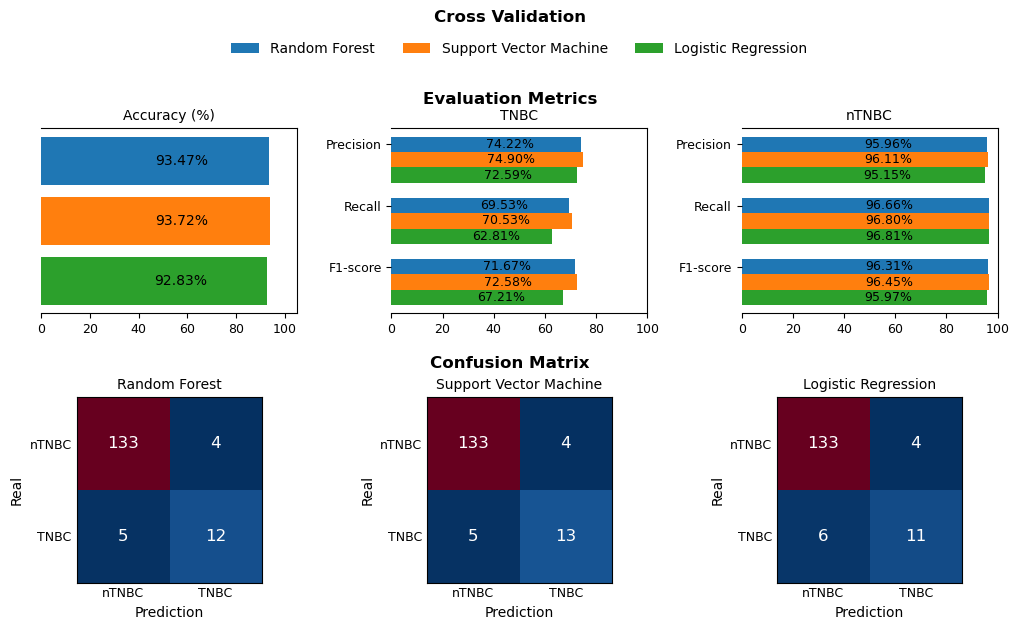



------------ Model Performance Results


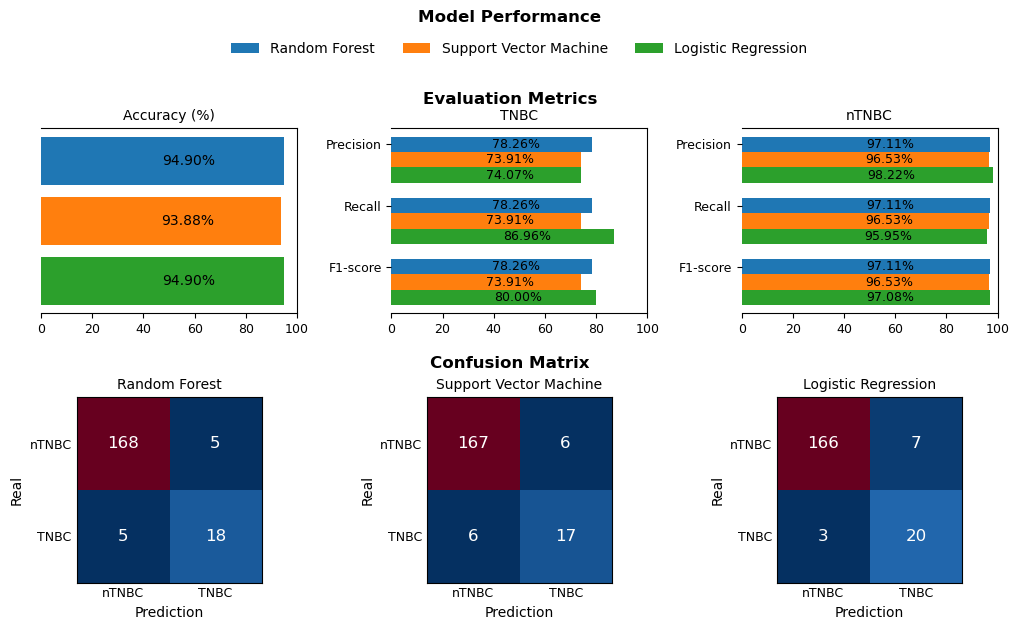



------------ ROC & AUC


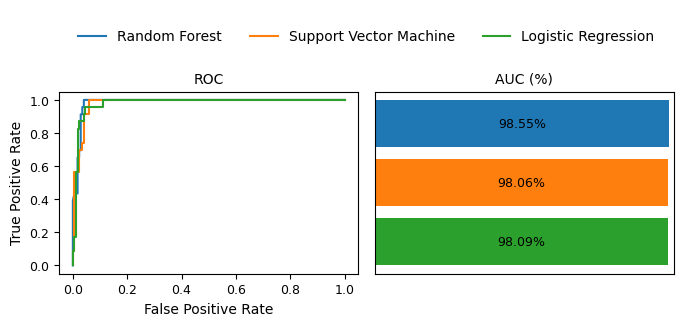

2/21 - FeatureSet literature - nSMOTE - End
3/21 - FeatureSet literature - Weighted - Start


------------ Cross-Validation Results


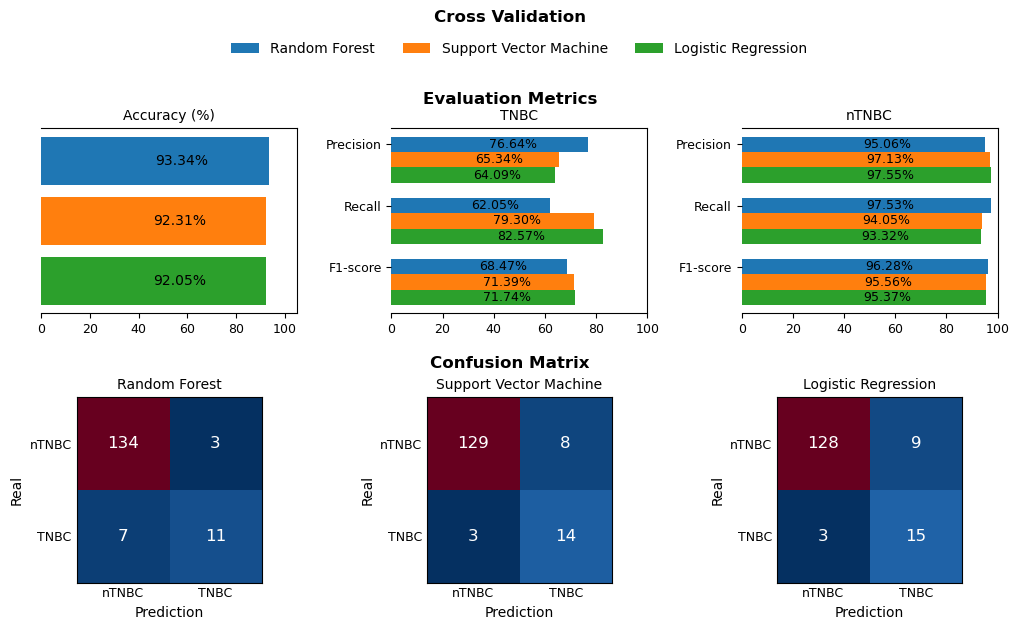



------------ Model Performance Results


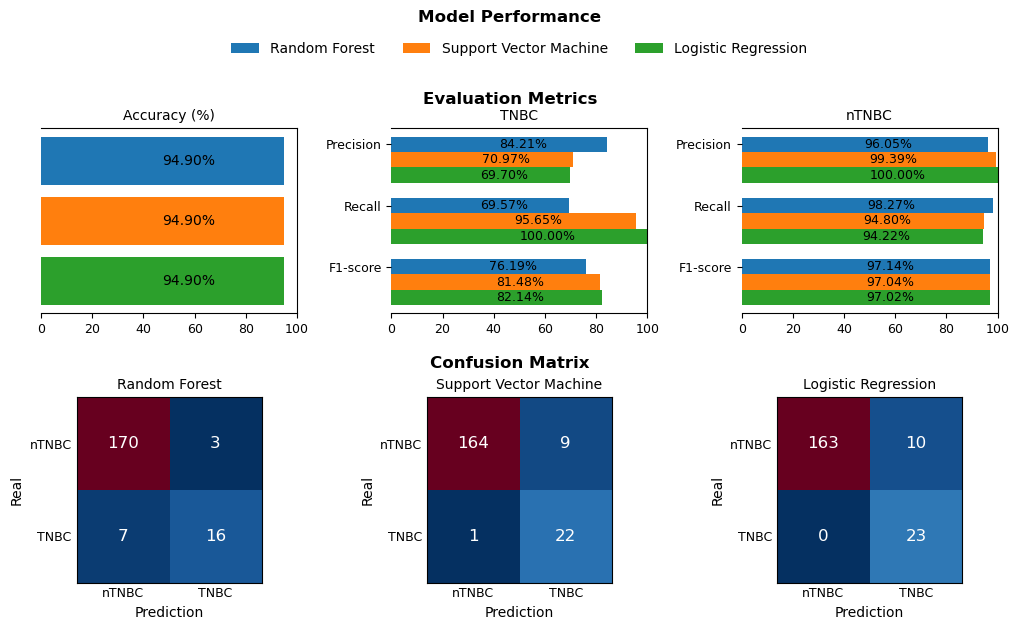



------------ ROC & AUC


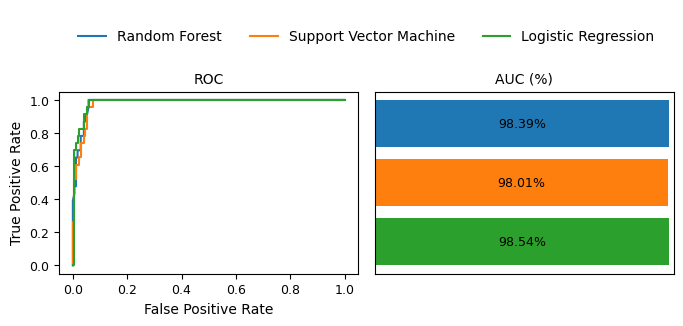

3/21 - FeatureSet literature - Weighted - End
4/21 - FeatureSet boruta - SMOTE - Start


------------ Cross-Validation Results


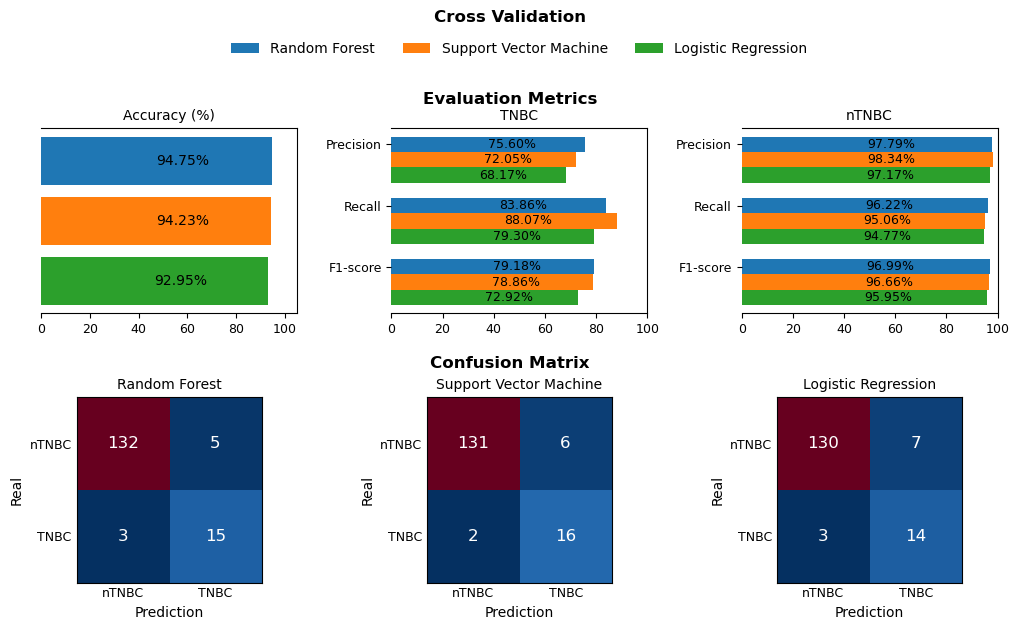



------------ Model Performance Results


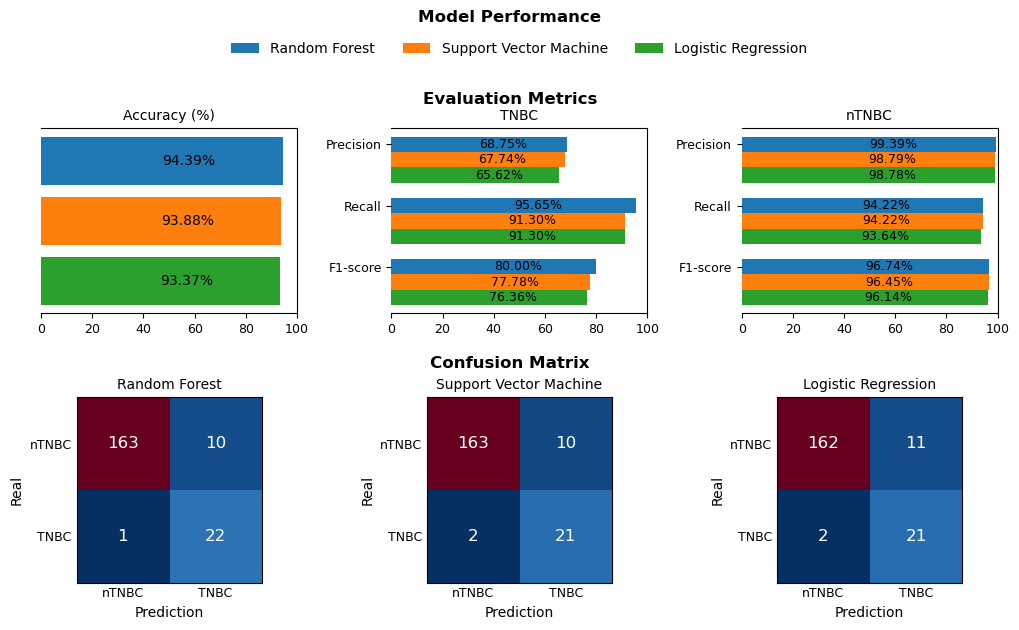



------------ ROC & AUC


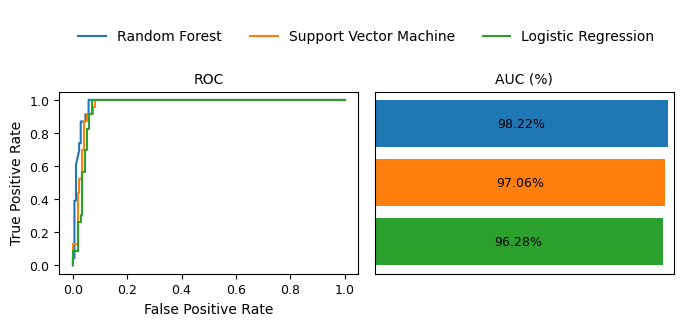

4/21 - FeatureSet boruta - SMOTE - End
5/21 - FeatureSet boruta - nSMOTE - Start


------------ Cross-Validation Results


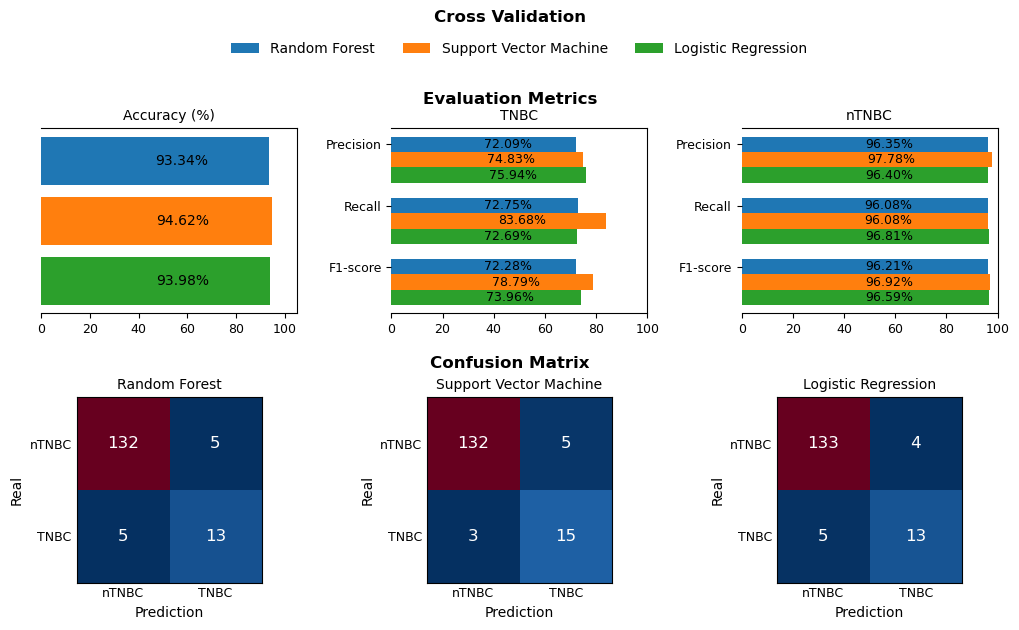



------------ Model Performance Results


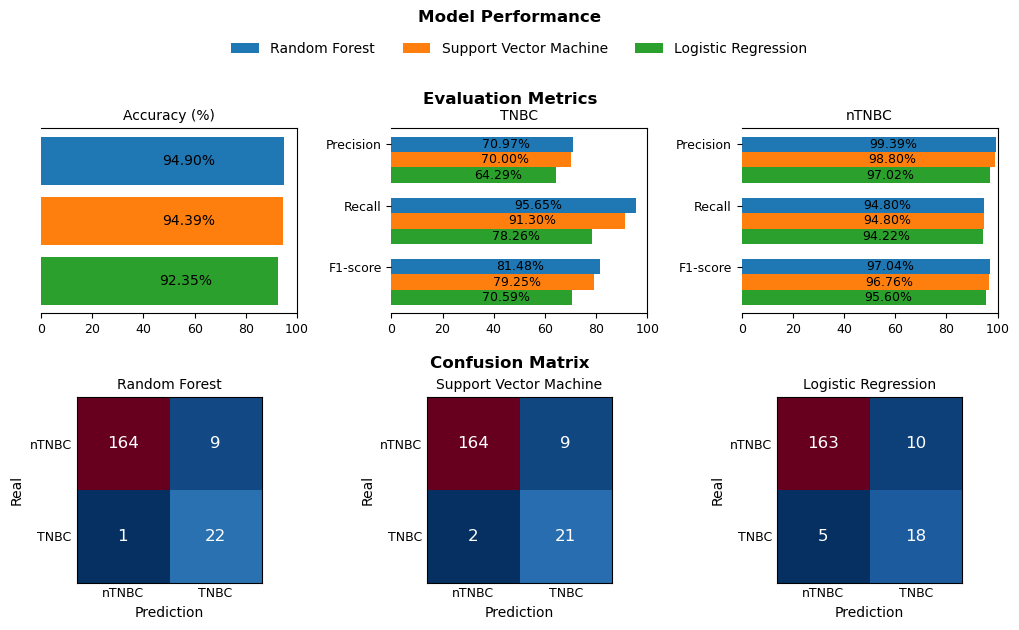



------------ ROC & AUC


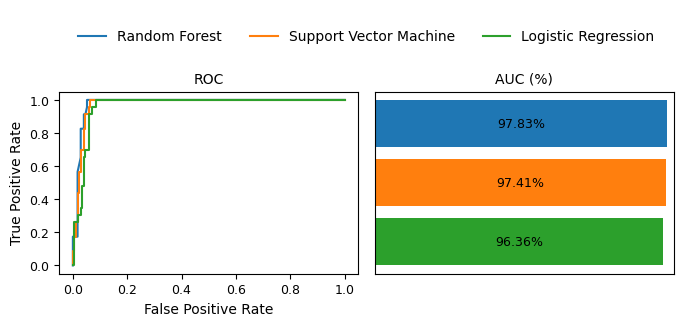

5/21 - FeatureSet boruta - nSMOTE - End
6/21 - FeatureSet boruta - Weighted - Start


------------ Cross-Validation Results


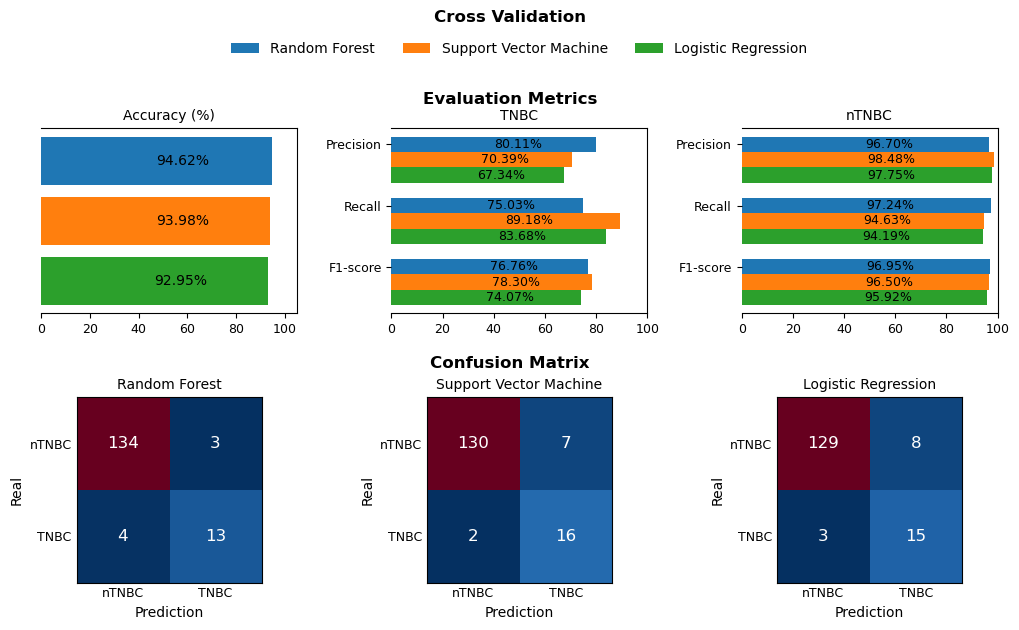



------------ Model Performance Results


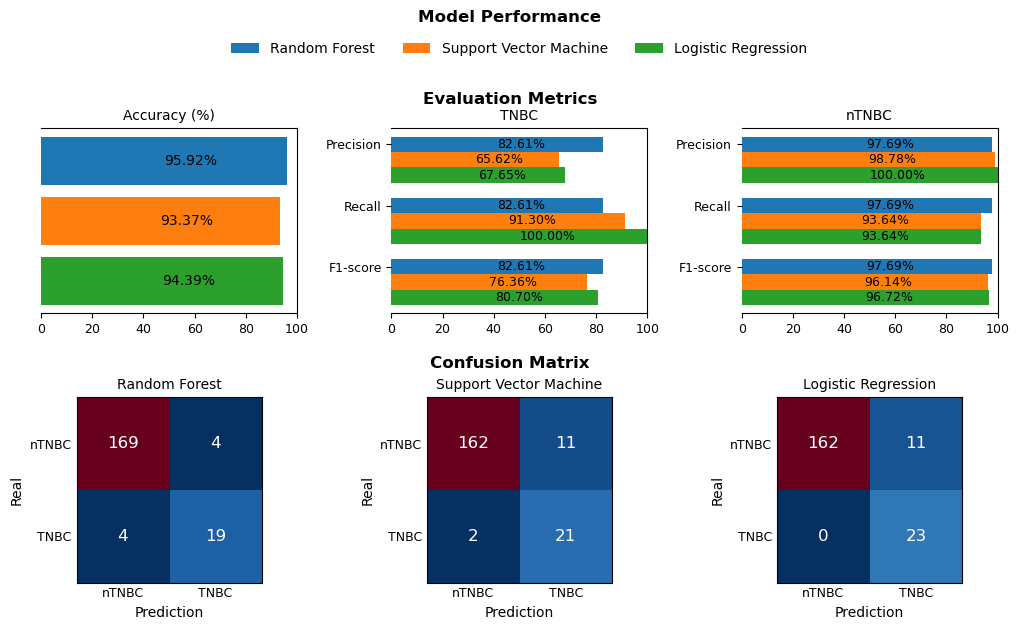



------------ ROC & AUC


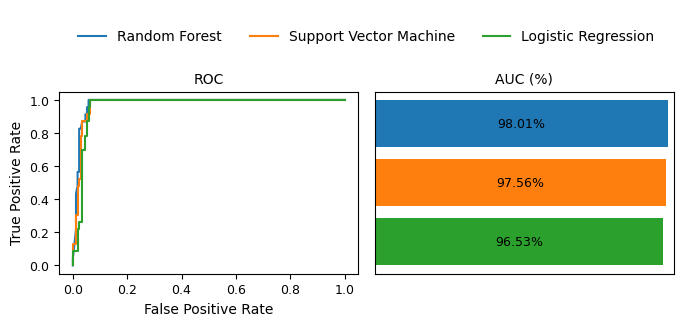

6/21 - FeatureSet boruta - Weighted - End
7/21 - FeatureSet rfe - SMOTE - Start


------------ Cross-Validation Results


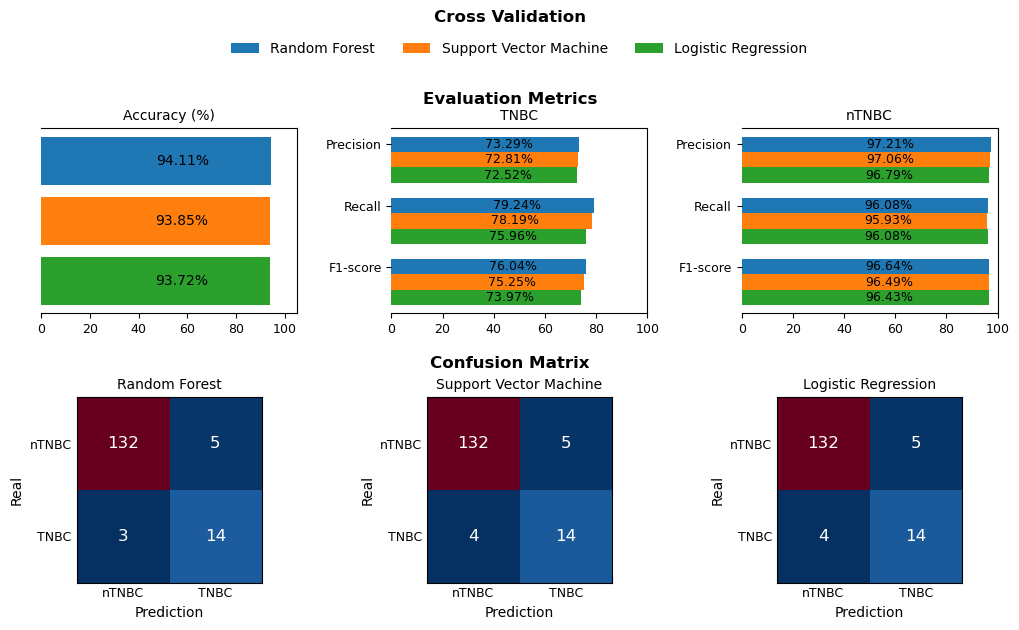



------------ Model Performance Results


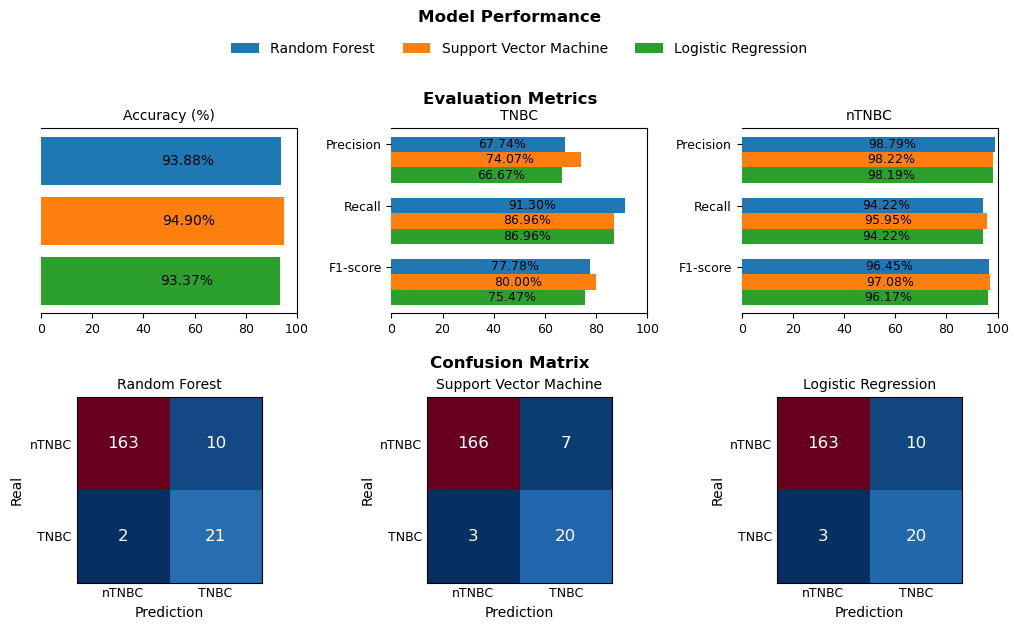



------------ ROC & AUC


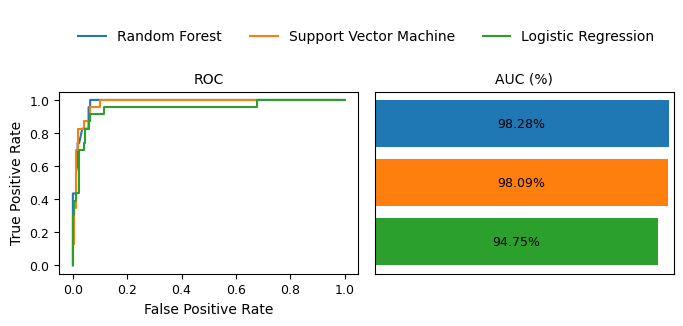

7/21 - FeatureSet rfe - SMOTE - End
8/21 - FeatureSet rfe - nSMOTE - Start


------------ Cross-Validation Results


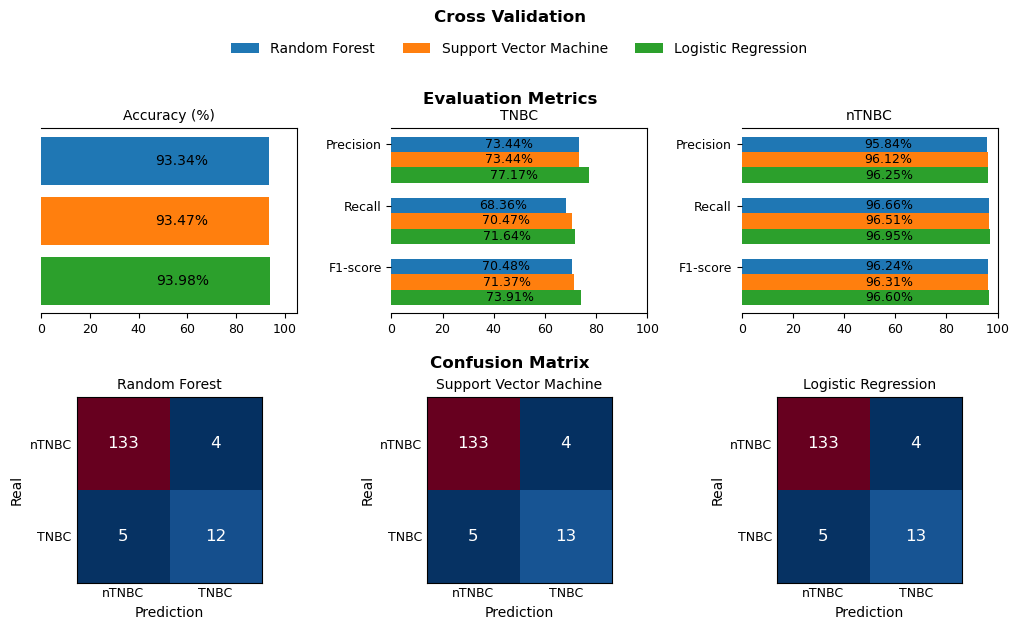



------------ Model Performance Results


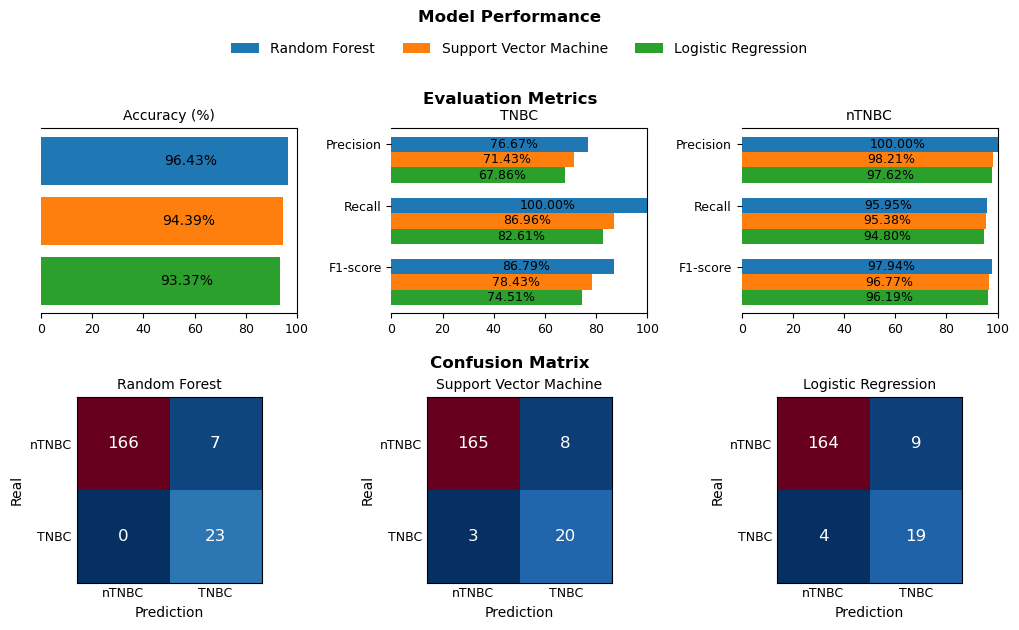



------------ ROC & AUC


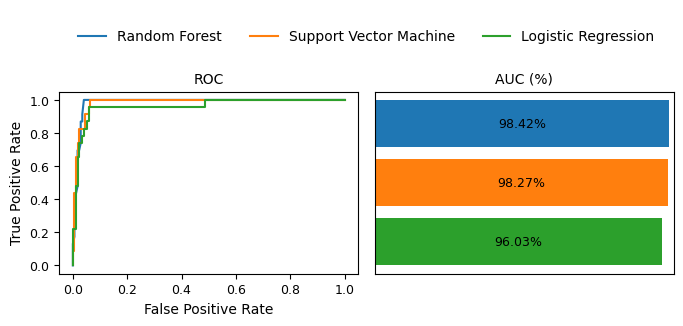

8/21 - FeatureSet rfe - nSMOTE - End
9/21 - FeatureSet rfe - Weighted - Start


------------ Cross-Validation Results


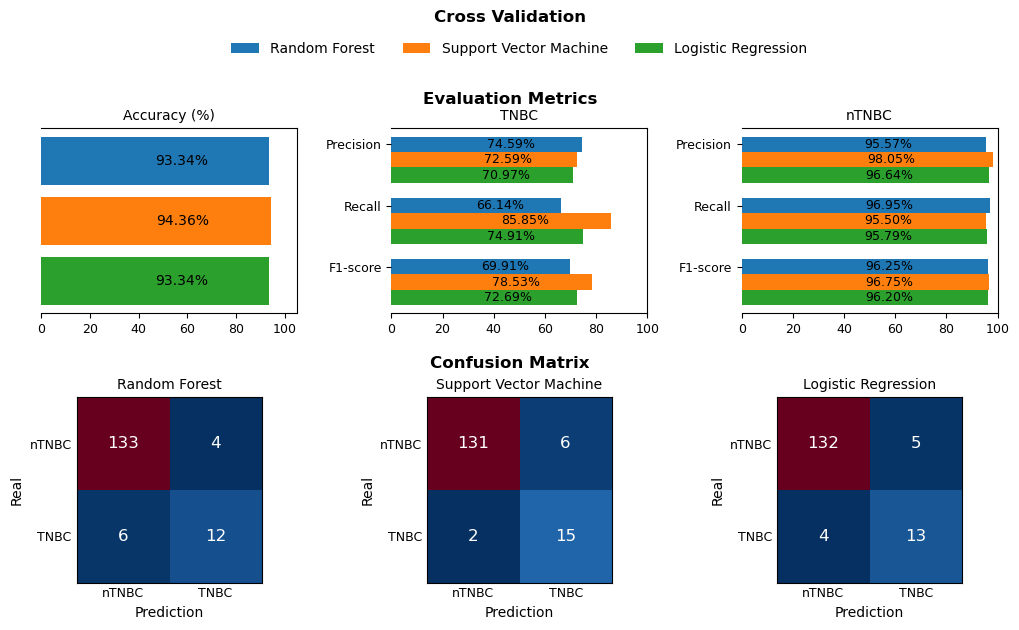



------------ Model Performance Results


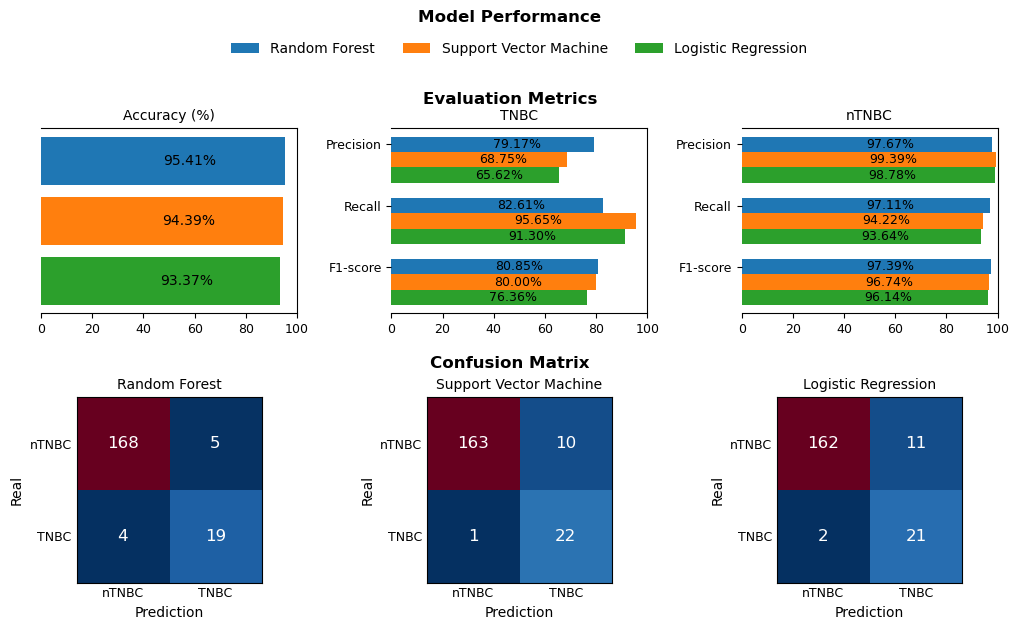



------------ ROC & AUC


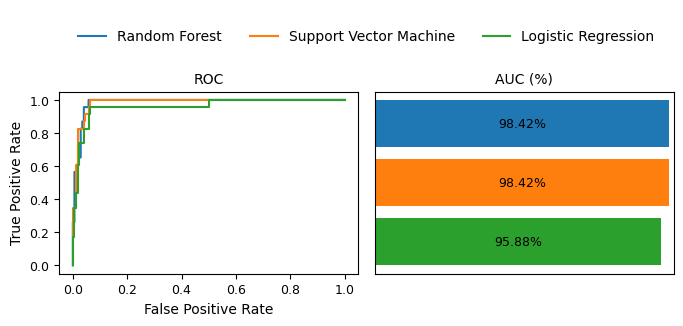

9/21 - FeatureSet rfe - Weighted - End
10/21 - FeatureSet lasso - SMOTE - Start


------------ Cross-Validation Results


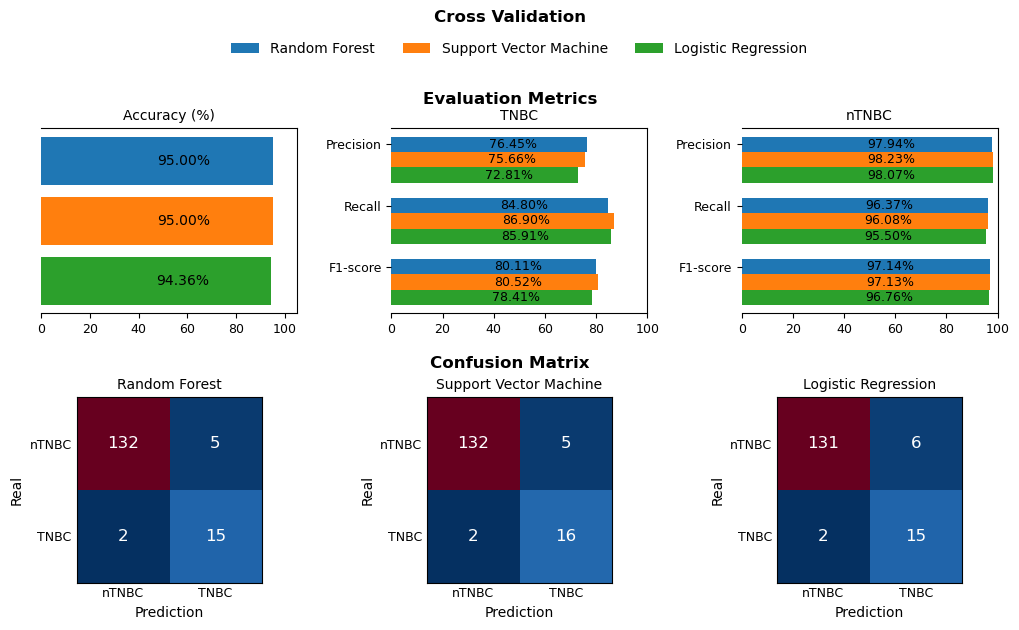



------------ Model Performance Results


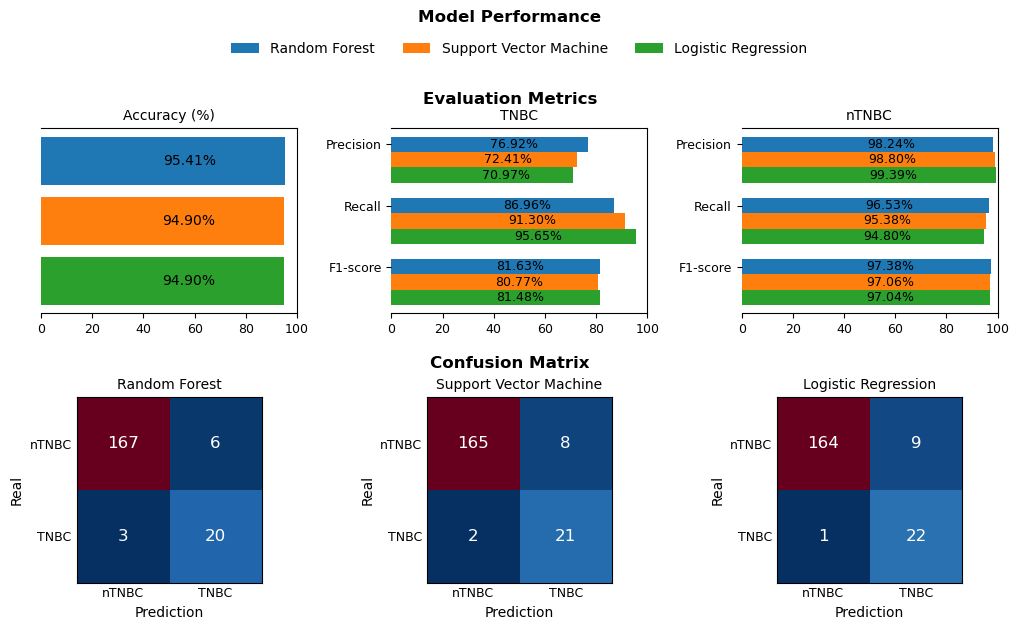



------------ ROC & AUC


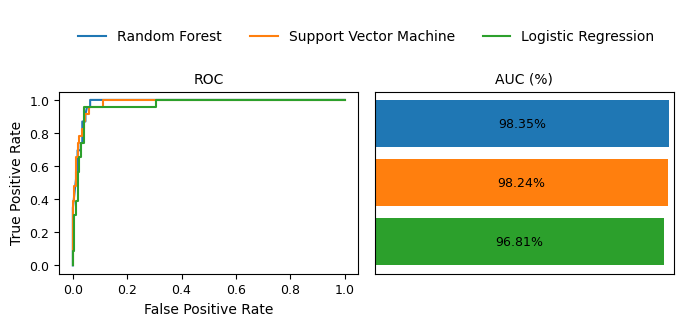

10/21 - FeatureSet lasso - SMOTE - End
11/21 - FeatureSet lasso - nSMOTE - Start


------------ Cross-Validation Results


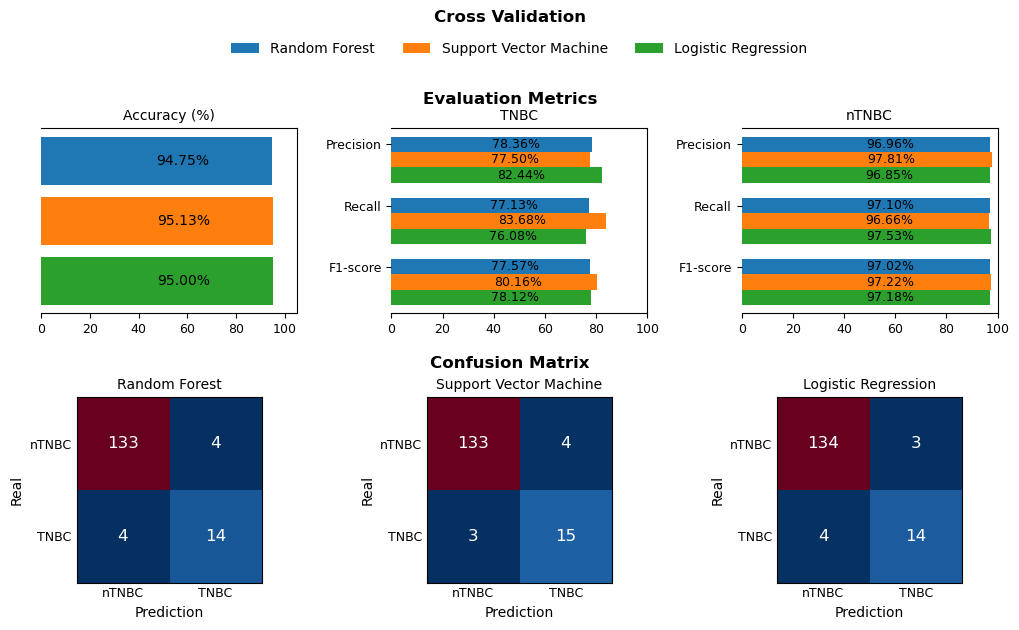



------------ Model Performance Results


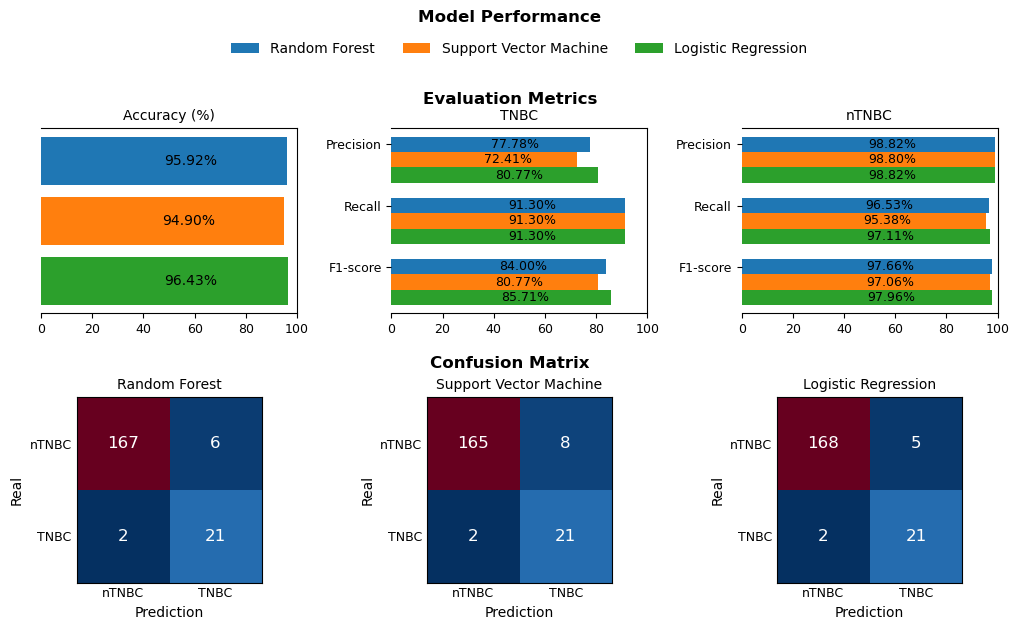



------------ ROC & AUC


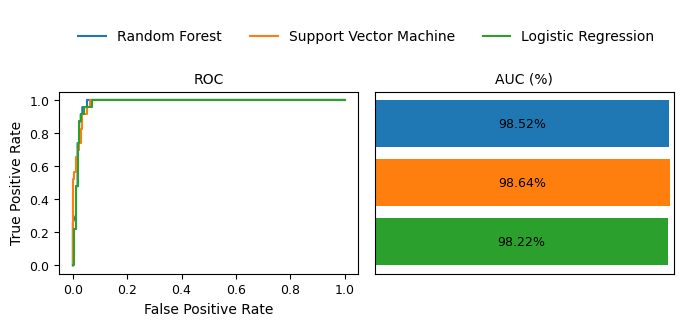

11/21 - FeatureSet lasso - nSMOTE - End
12/21 - FeatureSet lasso - Weighted - Start


------------ Cross-Validation Results


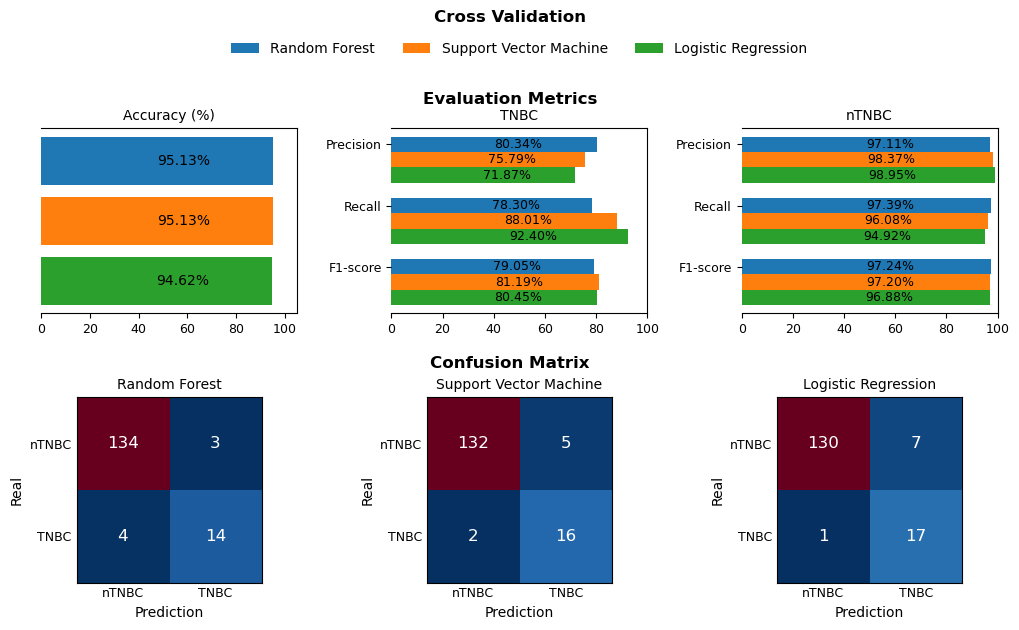



------------ Model Performance Results


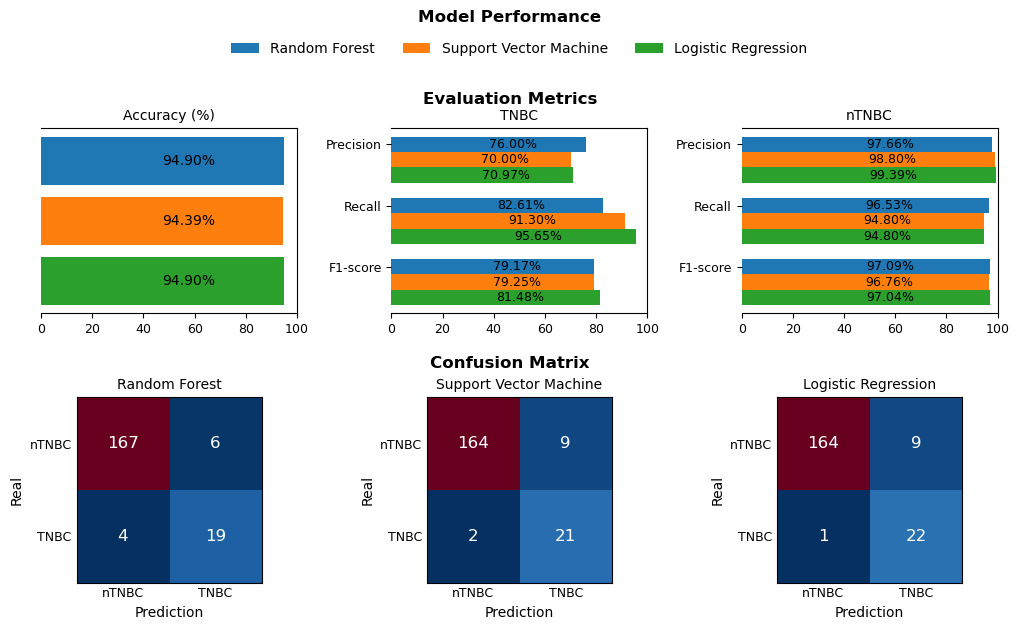



------------ ROC & AUC


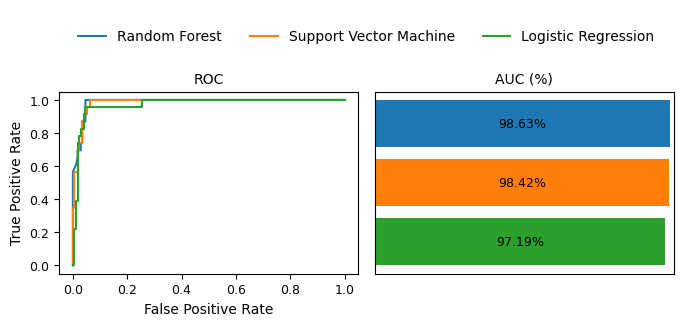

12/21 - FeatureSet lasso - Weighted - End
13/21 - FeatureSet kothari - SMOTE - Start


------------ Cross-Validation Results


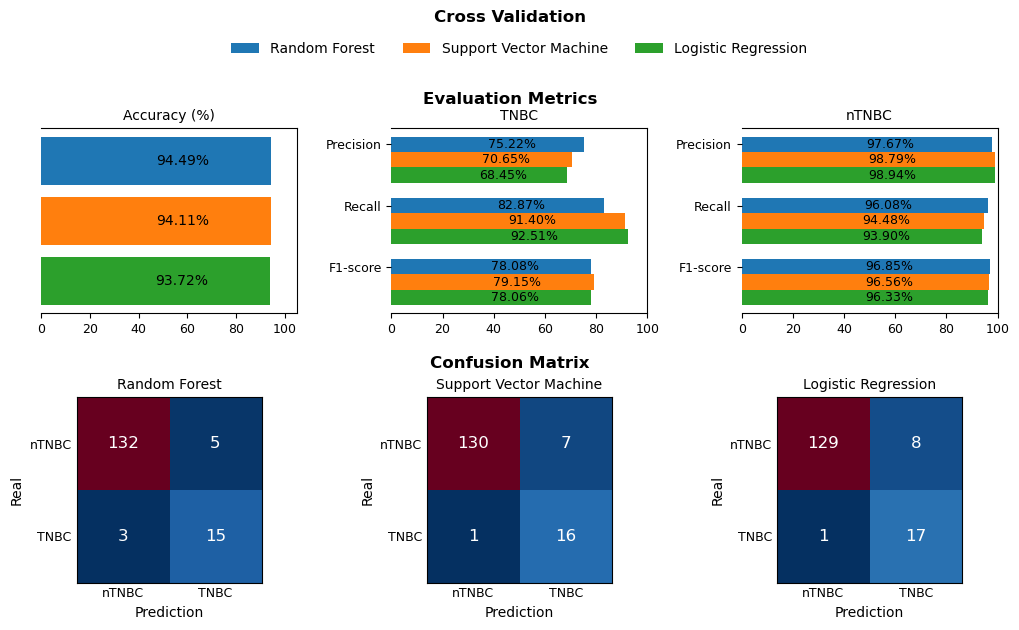



------------ Model Performance Results


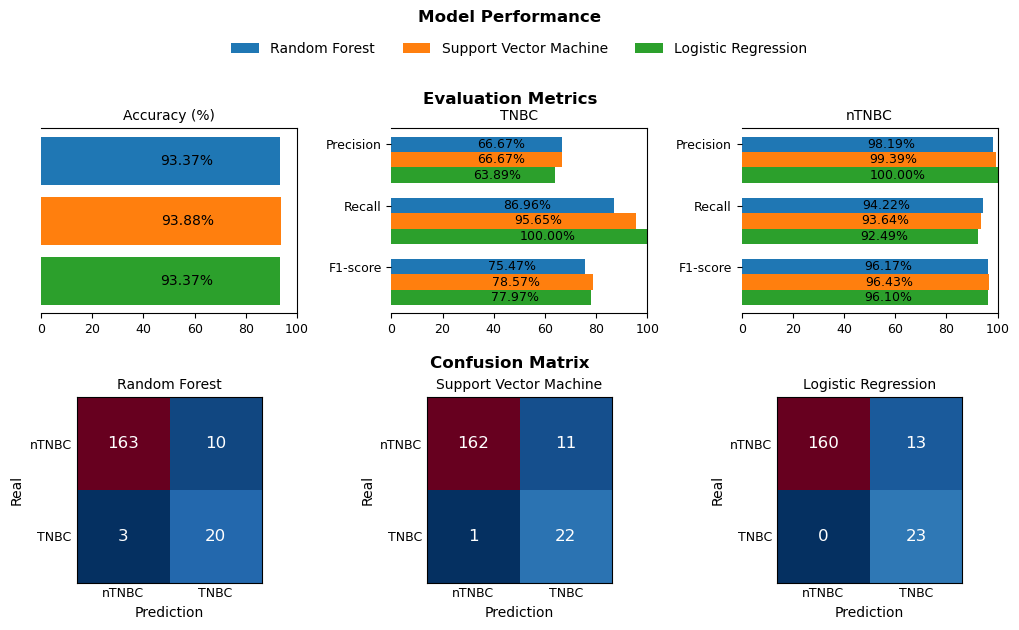



------------ ROC & AUC


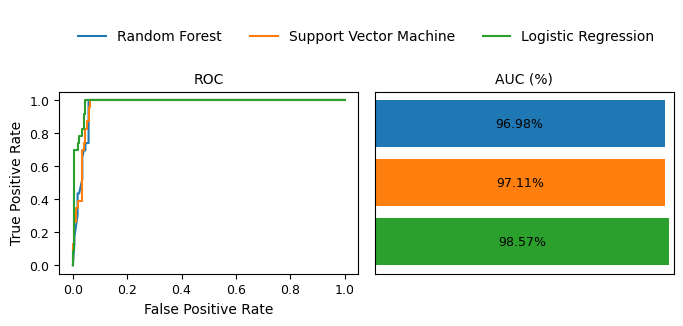

13/21 - FeatureSet kothari - SMOTE - End
14/21 - FeatureSet kothari - nSMOTE - Start


------------ Cross-Validation Results


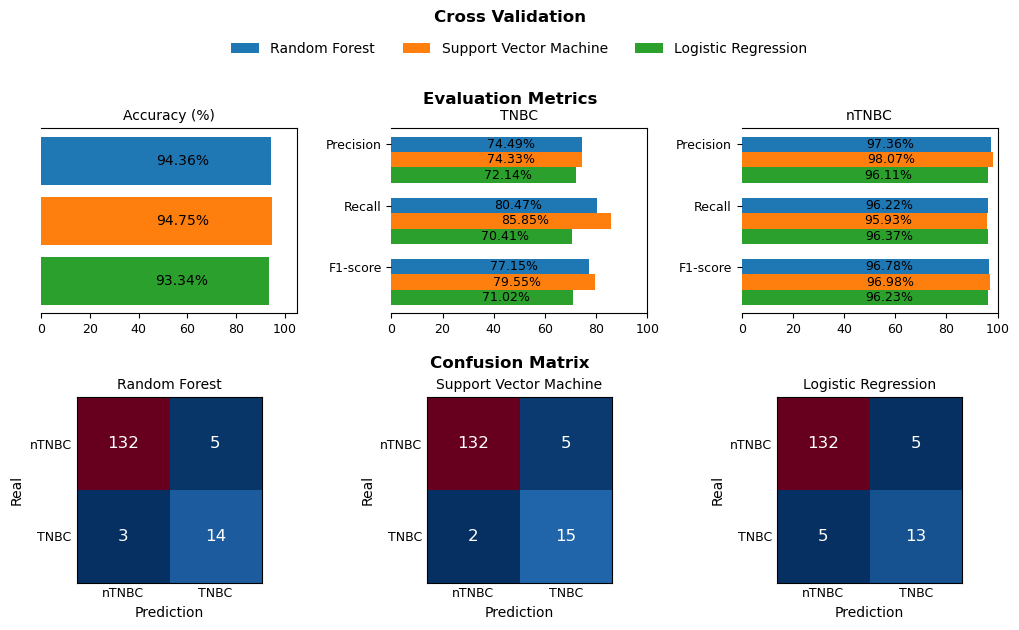



------------ Model Performance Results


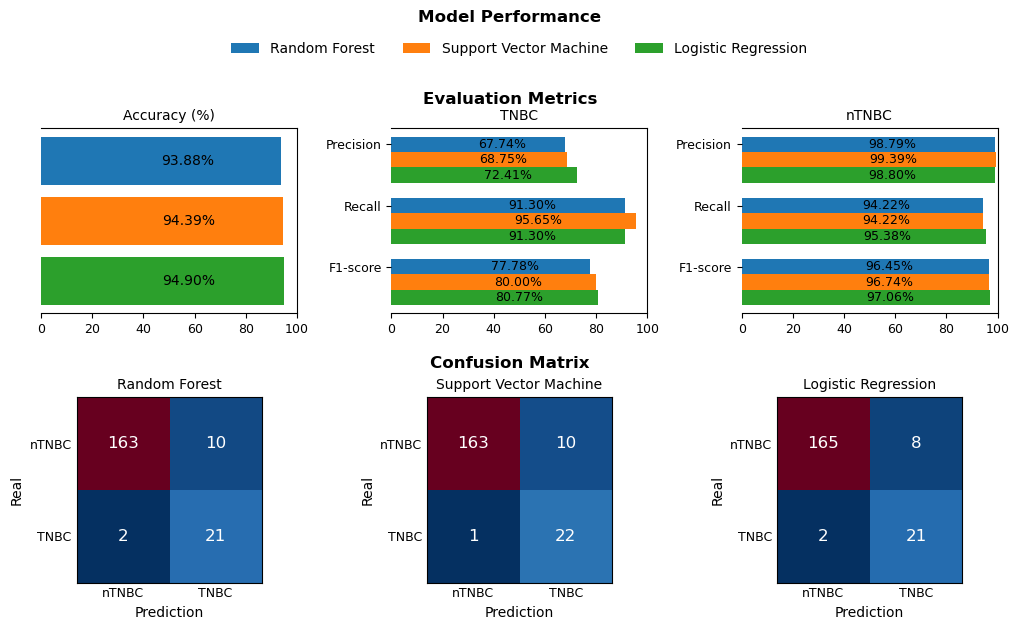



------------ ROC & AUC


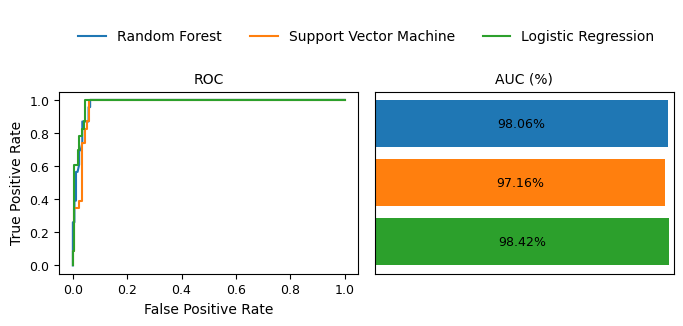

14/21 - FeatureSet kothari - nSMOTE - End
15/21 - FeatureSet kothari - Weighted - Start


------------ Cross-Validation Results


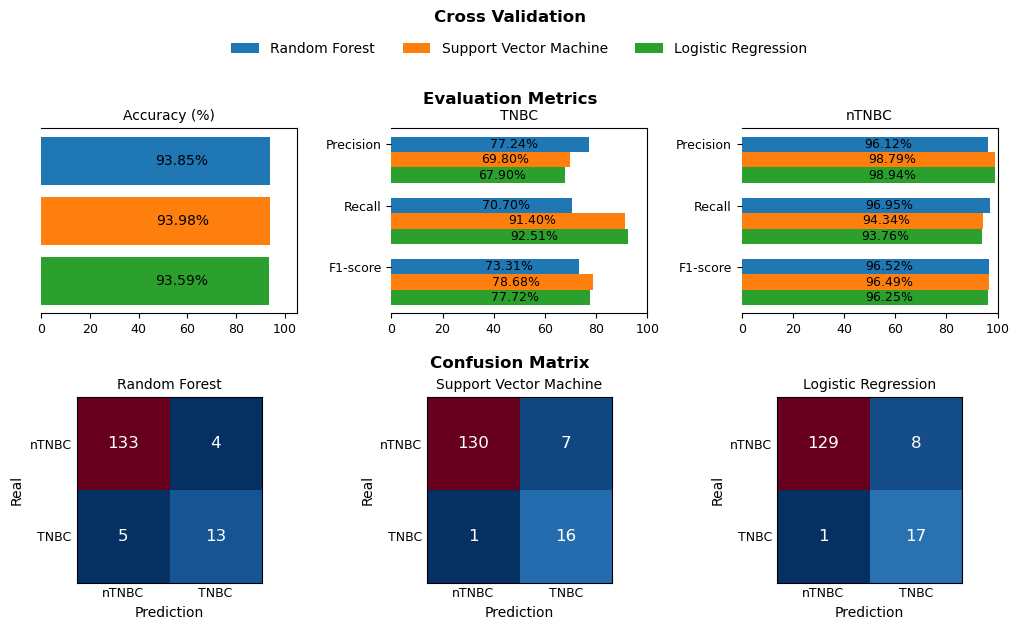



------------ Model Performance Results


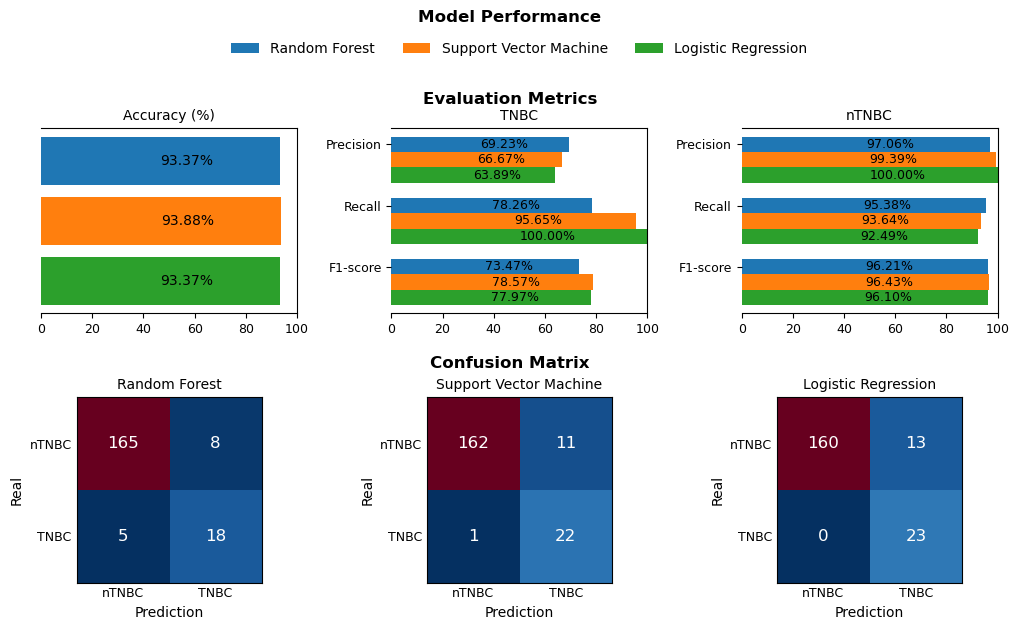



------------ ROC & AUC


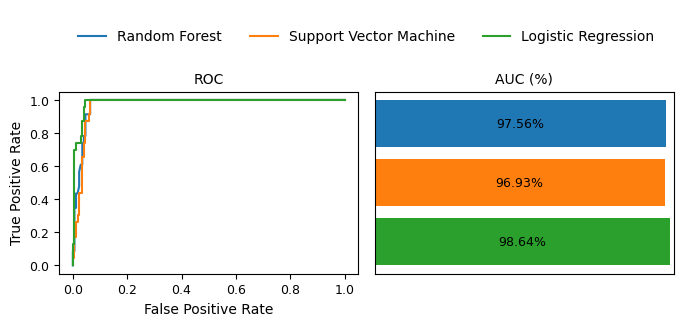

15/21 - FeatureSet kothari - Weighted - End
16/21 - FeatureSet statistical - SMOTE - Start


------------ Cross-Validation Results


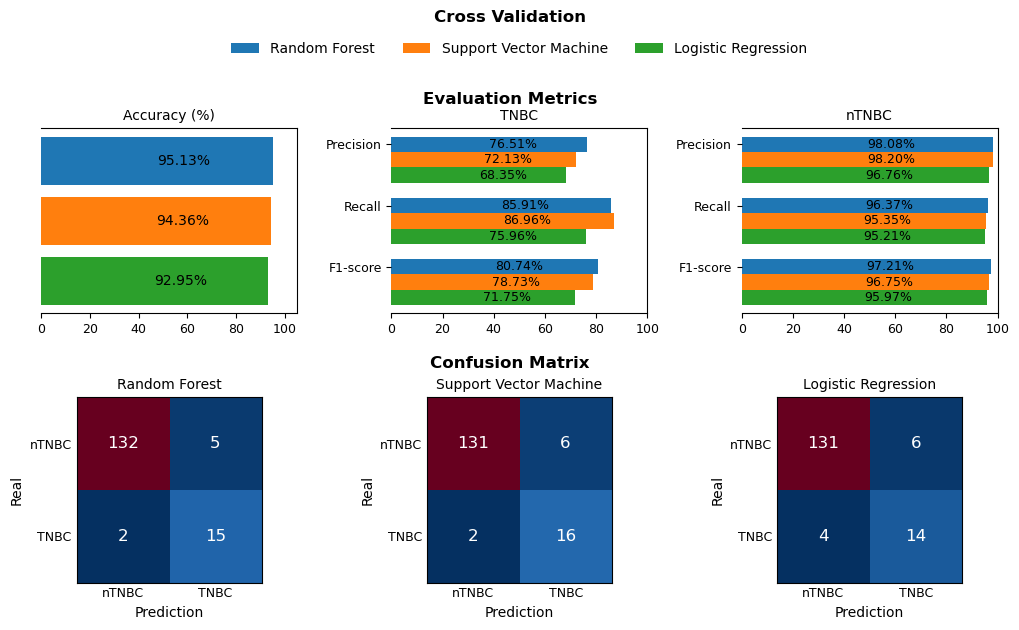



------------ Model Performance Results


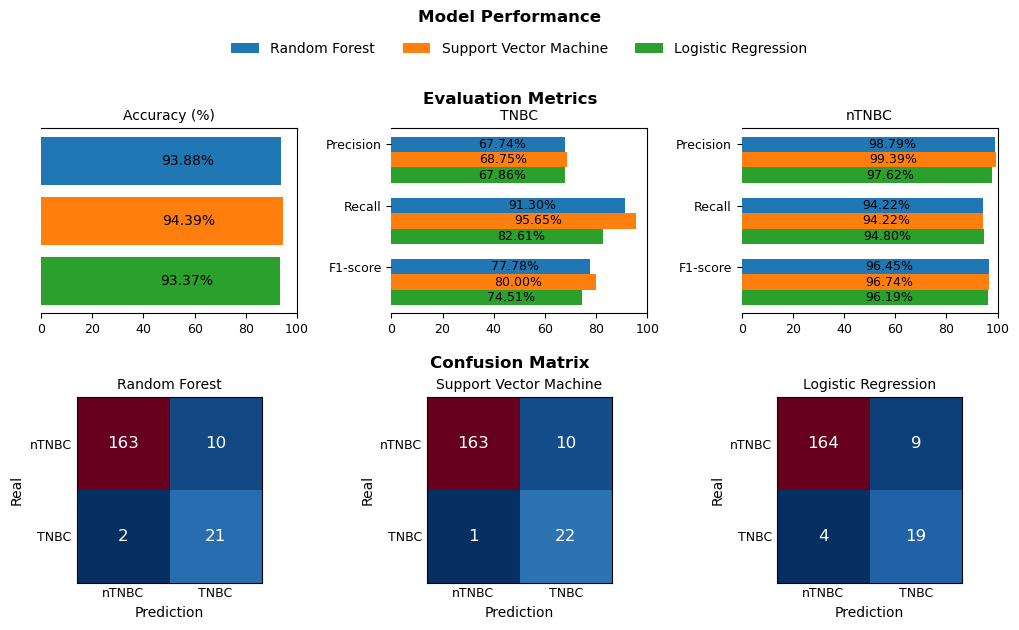



------------ ROC & AUC


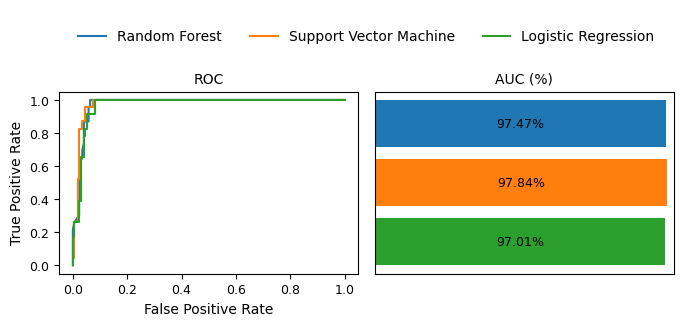

16/21 - FeatureSet statistical - SMOTE - End
17/21 - FeatureSet statistical - nSMOTE - Start


------------ Cross-Validation Results


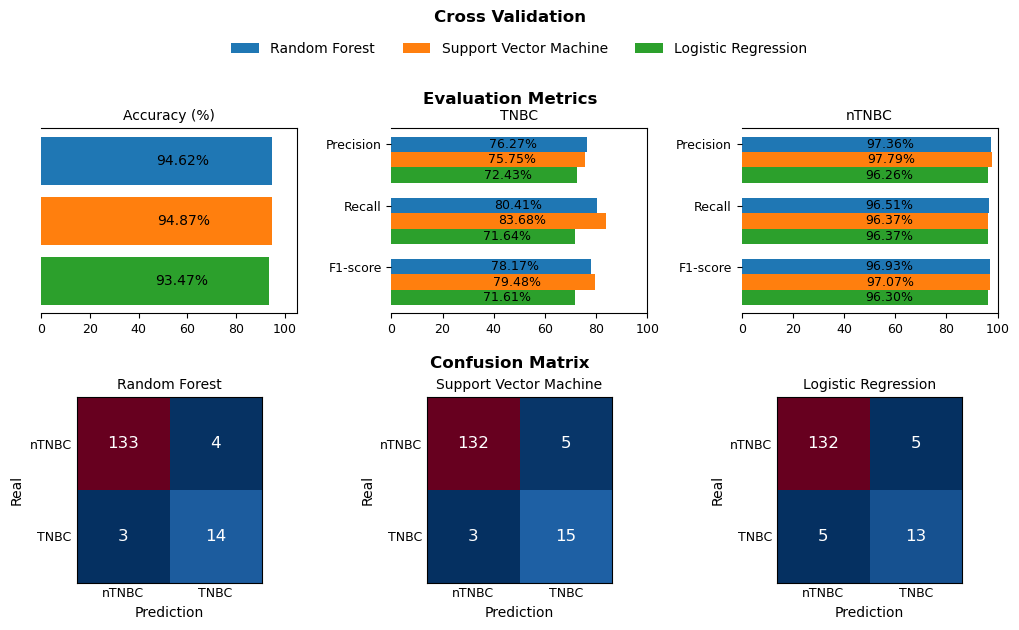



------------ Model Performance Results


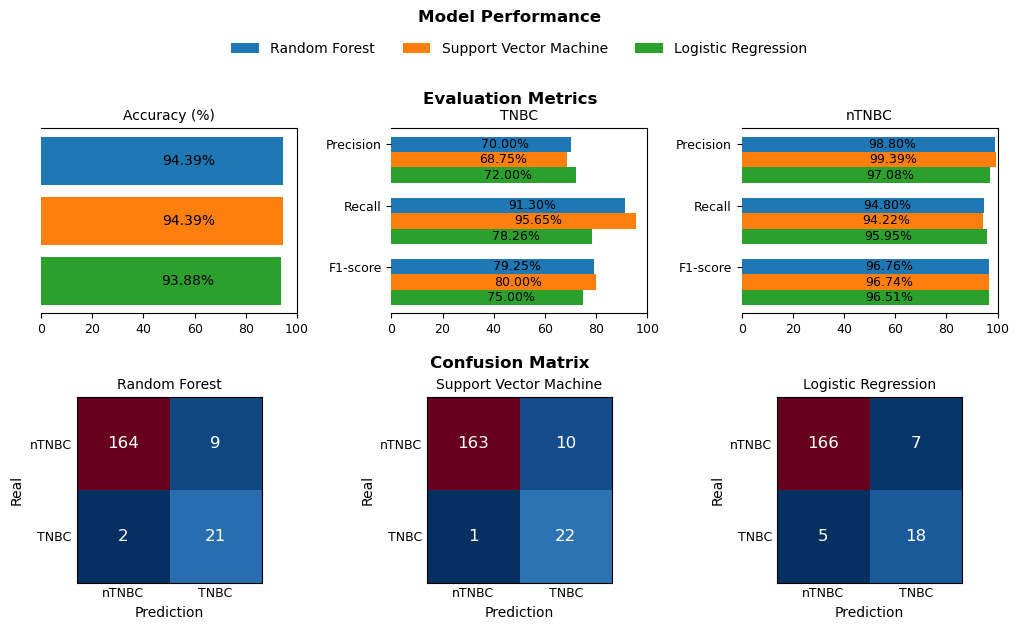



------------ ROC & AUC


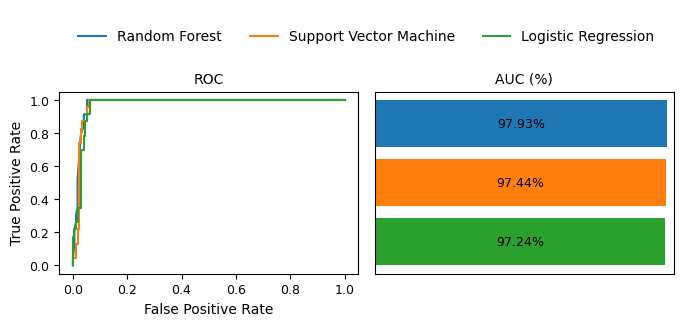

17/21 - FeatureSet statistical - nSMOTE - End
18/21 - FeatureSet statistical - Weighted - Start


------------ Cross-Validation Results


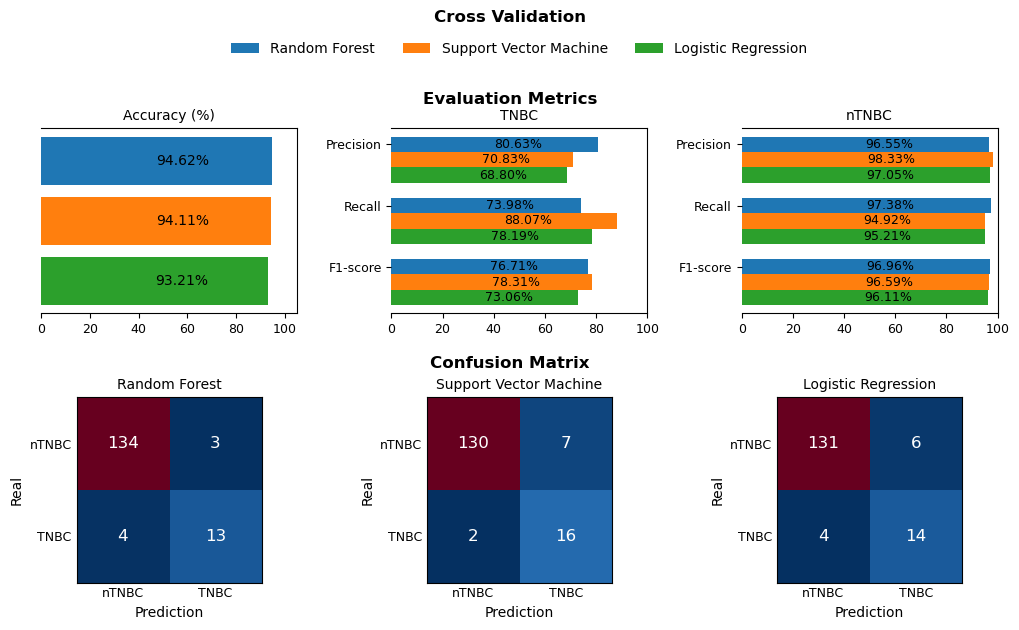



------------ Model Performance Results


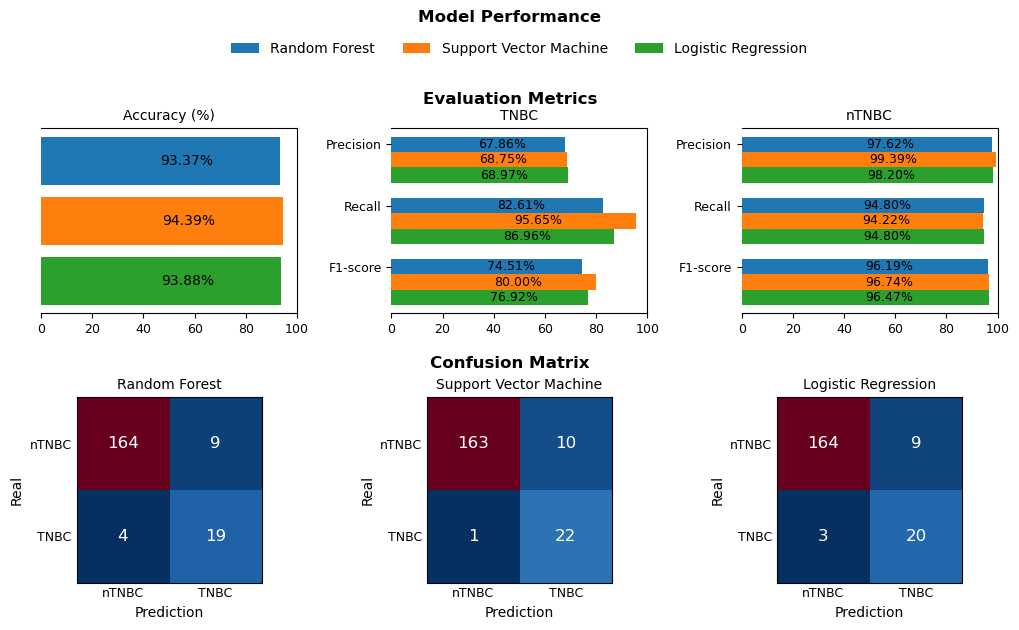



------------ ROC & AUC


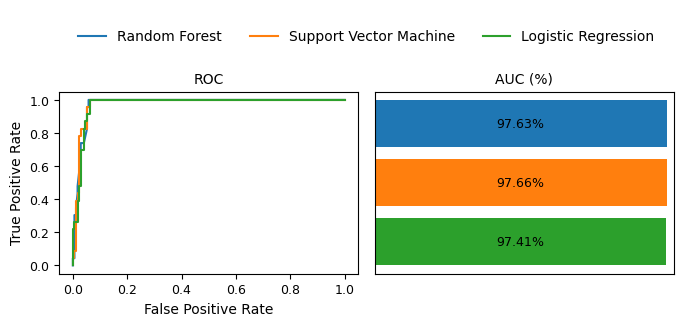

18/21 - FeatureSet statistical - Weighted - End
19/21 - FeatureSet automated - SMOTE - Start


------------ Cross-Validation Results


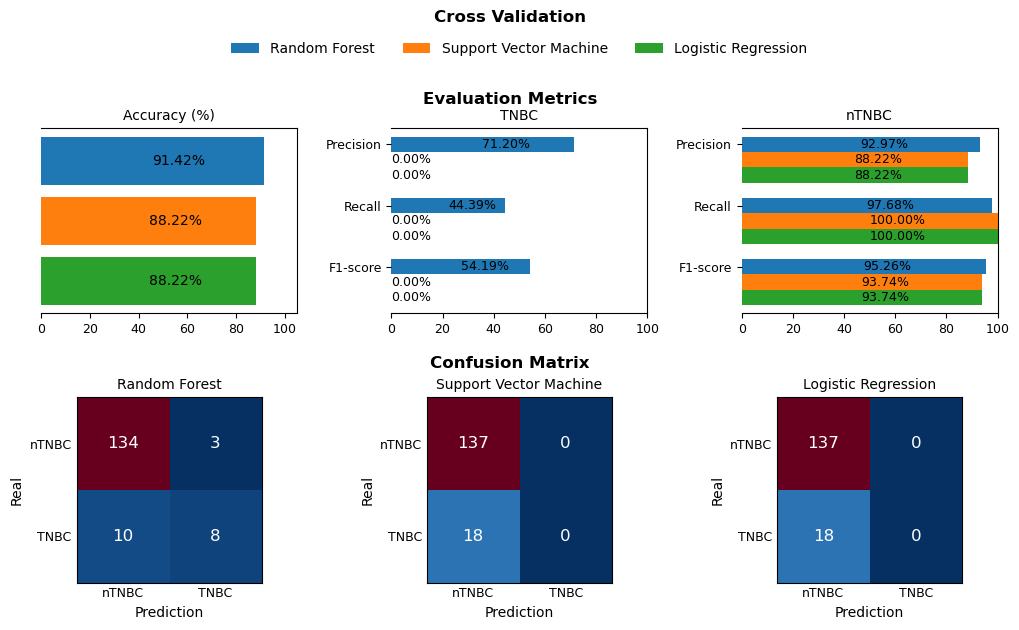



------------ Model Performance Results


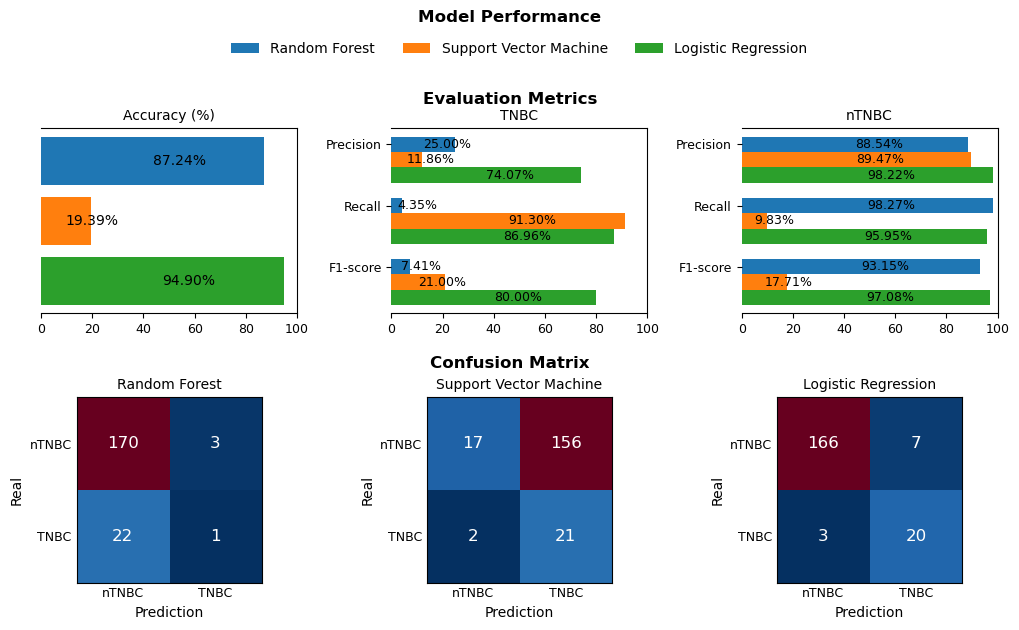



------------ ROC & AUC


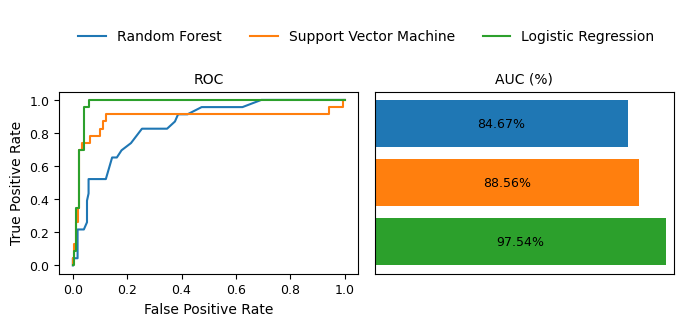

19/21 - FeatureSet automated - SMOTE - End
20/21 - FeatureSet automated - nSMOTE - Start


------------ Cross-Validation Results


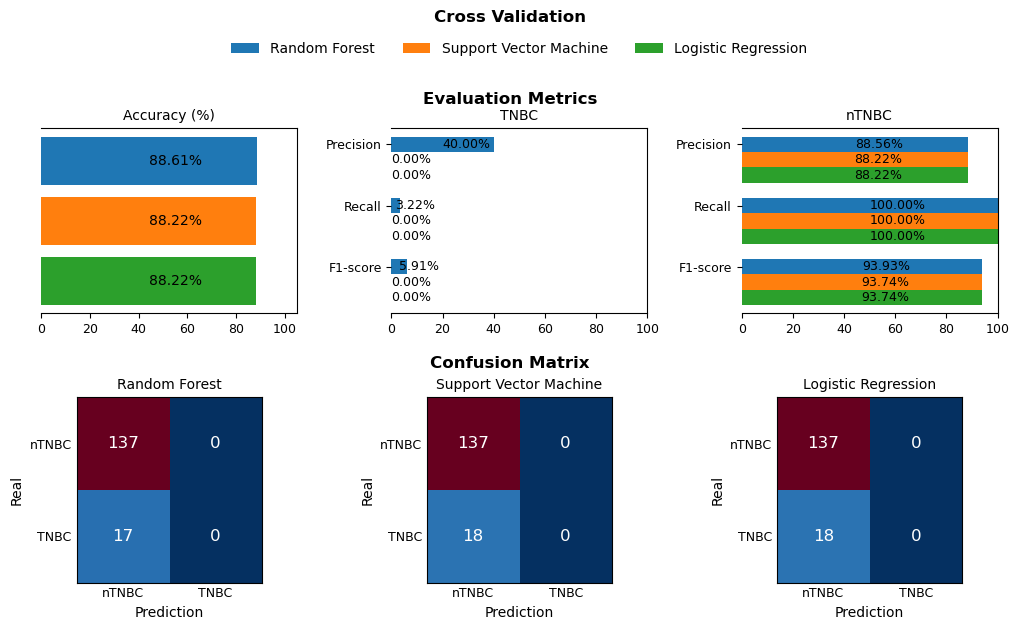



------------ Model Performance Results


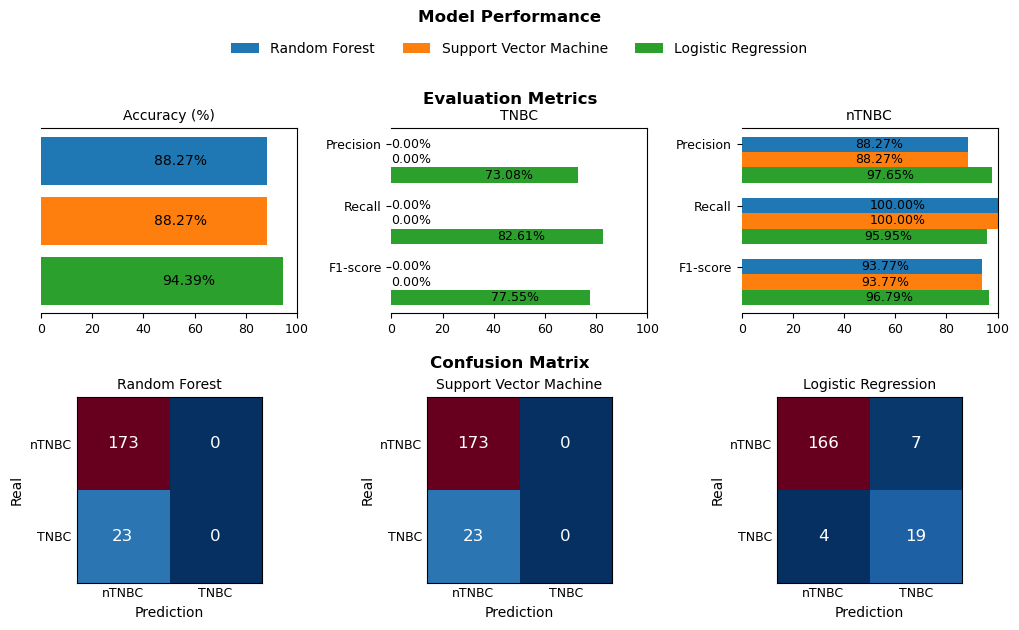



------------ ROC & AUC


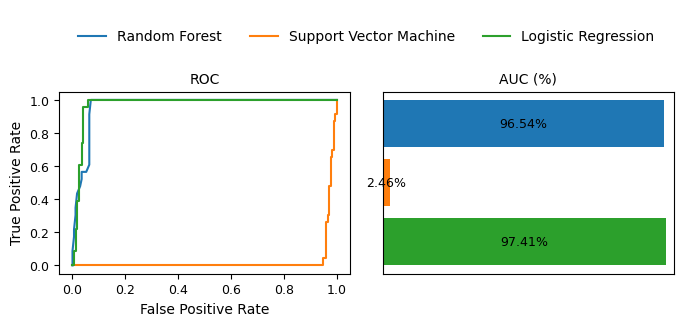

20/21 - FeatureSet automated - nSMOTE - End
21/21 - FeatureSet automated - Weighted - Start


------------ Cross-Validation Results


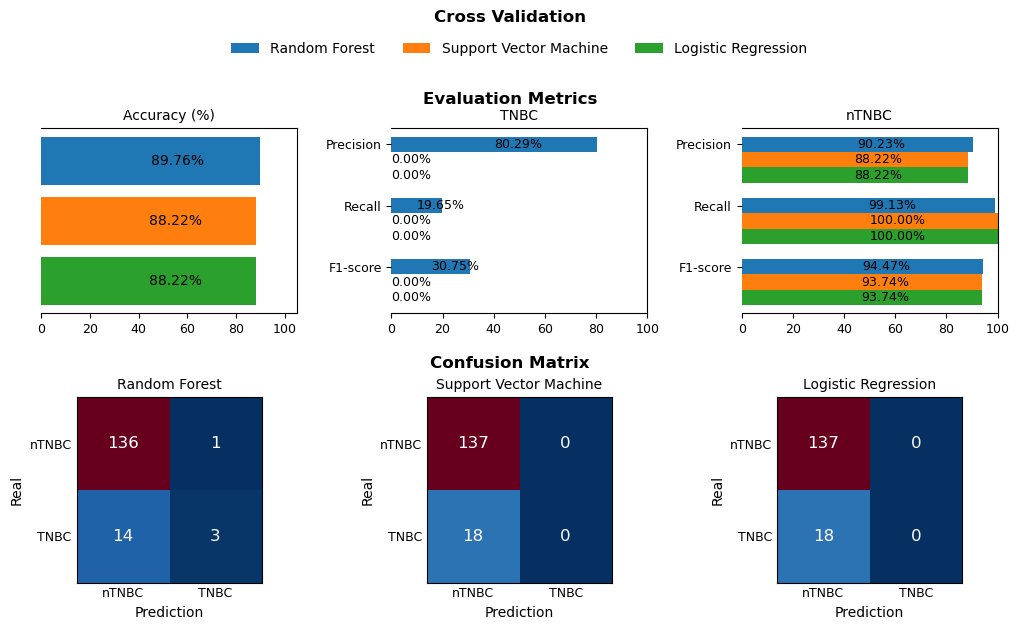



------------ Model Performance Results


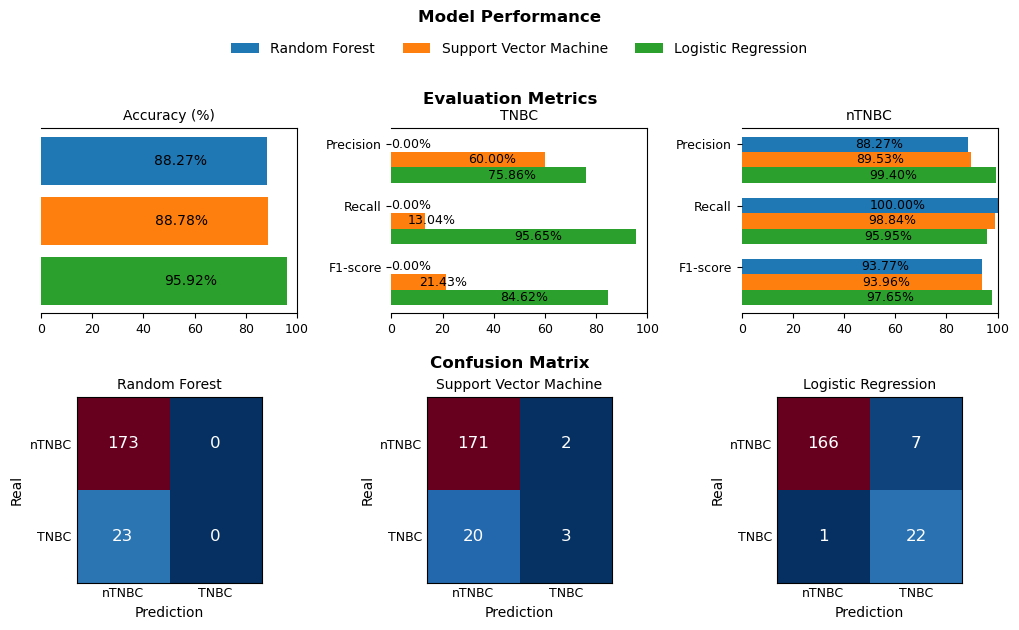



------------ ROC & AUC


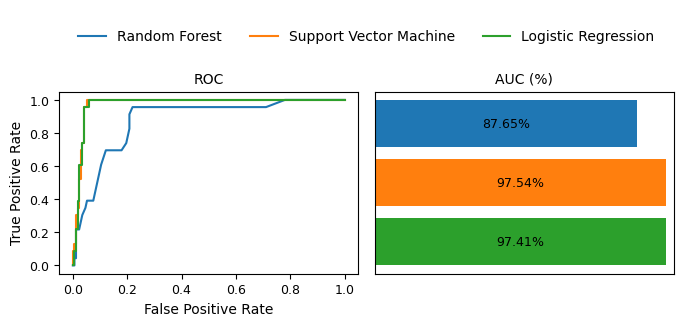

21/21 - FeatureSet automated - Weighted - End


In [3]:
modelStati = ['SMOTE', 'nSMOTE', 'Weighted']
total = len(FeatureVariant)*len(modelStati)
counter = 1

for GENE_FILE_VARIANT in FeatureVariant:
    for modelStatus in modelStati:
        print(f"{counter}/{total} - FeatureSet {GENE_FILE_VARIANT} - {modelStatus} - Start")
    
        #======================================
        # Get Metrics and Output of Models from Files
        #======================================
        MODEL_VARIANT_SVM = 'SVM'
        MODEL_VARIANT_RF  = 'RF'
        MODEL_VARIANT_LG  = 'LG'

        if 'nSMOTE' == modelStatus:
            FILE_PATH_LG_OUTPUT  = f"../Data/output/model_output_{MODEL_VARIANT_LG}_{GENE_FILE_VARIANT}.csv"
            FILE_PATH_RF_OUTPUT  = f"../Data/output/model_output_{MODEL_VARIANT_RF}_{GENE_FILE_VARIANT}.csv"
            FILE_PATH_SVM_OUTPUT = f"../Data/output/model_output_{MODEL_VARIANT_SVM}_{GENE_FILE_VARIANT}.csv"
            
            FILE_PATH_LG_METRICS  = f"../Data/output/model_metrics_{MODEL_VARIANT_LG}_{GENE_FILE_VARIANT}.parquet"
            FILE_PATH_RF_METRICS  = f"../Data/output/model_metrics_{MODEL_VARIANT_RF}_{GENE_FILE_VARIANT}.parquet"
            FILE_PATH_SVM_METRICS = f"../Data/output/model_metrics_{MODEL_VARIANT_SVM}_{GENE_FILE_VARIANT}.parquet"
        elif 'SMOTE' == modelStatus:
            FILE_PATH_LG_OUTPUT  = f"../Data/output/model_output_{MODEL_VARIANT_LG}_{GENE_FILE_VARIANT}_smote.csv"
            FILE_PATH_RF_OUTPUT  = f"../Data/output/model_output_{MODEL_VARIANT_RF}_{GENE_FILE_VARIANT}_smote.csv"
            FILE_PATH_SVM_OUTPUT = f"../Data/output/model_output_{MODEL_VARIANT_SVM}_{GENE_FILE_VARIANT}_smote.csv"
            
            FILE_PATH_LG_METRICS  = f"../Data/output/model_metrics_{MODEL_VARIANT_LG}_{GENE_FILE_VARIANT}_smote.parquet"
            FILE_PATH_RF_METRICS  = f"../Data/output/model_metrics_{MODEL_VARIANT_RF}_{GENE_FILE_VARIANT}_smote.parquet"
            FILE_PATH_SVM_METRICS = f"../Data/output/model_metrics_{MODEL_VARIANT_SVM}_{GENE_FILE_VARIANT}_smote.parquet"
        else:
            FILE_PATH_LG_OUTPUT  = f"../Data/output/model_output_{MODEL_VARIANT_LG}_{GENE_FILE_VARIANT}_weighted.csv"
            FILE_PATH_RF_OUTPUT  = f"../Data/output/model_output_{MODEL_VARIANT_RF}_{GENE_FILE_VARIANT}_weighted.csv"
            FILE_PATH_SVM_OUTPUT = f"../Data/output/model_output_{MODEL_VARIANT_SVM}_{GENE_FILE_VARIANT}_weighted.csv"
            
            FILE_PATH_LG_METRICS  = f"../Data/output/model_metrics_{MODEL_VARIANT_LG}_{GENE_FILE_VARIANT}_weighted.parquet"
            FILE_PATH_RF_METRICS  = f"../Data/output/model_metrics_{MODEL_VARIANT_RF}_{GENE_FILE_VARIANT}_weighted.parquet"
            FILE_PATH_SVM_METRICS = f"../Data/output/model_metrics_{MODEL_VARIANT_SVM}_{GENE_FILE_VARIANT}_weighted.parquet"
    
        #======================================
        # Process data of Files into Dictionary
        #======================================
        # Output files to load variants for
        variants = {
            "Random Forest": FILE_PATH_RF_OUTPUT,
            "Support Vector Machine": FILE_PATH_SVM_OUTPUT,
            "Logistic Regression": FILE_PATH_LG_OUTPUT,
        }
        # Cross-validation metrics files to load variants for
        variantMetrics = {
            "Random Forest": FILE_PATH_RF_METRICS,
            "Support Vector Machine": FILE_PATH_SVM_METRICS,
            "Logistic Regression": FILE_PATH_LG_METRICS,
        }
        baseColors = [] # To override the first couple of base colors, add them here (removed because unnecessary)
        getColors = lambda n: ([ # Lambda to generate as many base colors as needed
            to_hex(plt.get_cmap('tab10')((i + len(baseColors)) % plt.get_cmap('tab10').N))
            for i in range(max(0, n - len(baseColors)))
        ])[:n]
        
        # Definitions
        evalPrecision = 'precision'
        evalRecall = 'recall'
        evalF1score = 'f1-score'
        
        evalTargetN = 'nTNBC'
        evalTarget = 'TNBC'
        
        targetNames = [evalTargetN, evalTarget]
        classLabels = ['Precision', 'Recall', 'F1-score']
        models = variants.keys()
        
        notTNBCData = {}
        TNBCData = {}
        accuracyData = {}
        confusionMatrixes = {}
        
        # Read evaluation data for all files
        for model, file in variants.items():
            df = pd.read_csv(file)
        
            y_test = df['y_test']
            y_pred = df['y_pred']
            
            classification = classification_report(y_test, y_pred, output_dict=True, target_names=targetNames, zero_division=0)
            confusionMatrix = confusion_matrix(y_test, y_pred)
            accuracy = accuracy_score(y_test, y_pred)
        
            notTNBCData[model] = (classification[evalTargetN][evalPrecision]*100 , classification[evalTargetN][evalRecall]*100 , classification[evalTargetN][evalF1score]*100 )
            TNBCData[model] = (classification[evalTarget][evalPrecision]*100 , classification[evalTarget][evalRecall]*100 , classification[evalTarget][evalF1score]*100 )
            accuracyData[model] = accuracy*100
            confusionMatrixes[model] = confusionMatrix

        # --- legibility controls ---
        SCALE               = 0.70         # ~50% size so two sets fit side-by-side
        FS_TITLE            = 10        
        FS_AXIS             = 10           # axis label font size
        FS_TICKS            = 9            # tick label font size (incl. classLabels)
        FS_LEGEND           = 10           # legend font size
        FS_BARVAL           = 10            # bar value label font size
        FS_BARVAL_ACCURACY  = 11           # bar value label font size
        FS_CM               = 12           # confusion matrix numbers font size
        CM_TEXT_COLOR       = "white"      # requested: white numbers inside confusion matrix



    
        print(f"\n\n------------ Cross-Validation Results")
        #======================================
        # Get 5 Fold data
        #======================================
        notTNBCData5Fold = {}
        TNBCData5Fold = {}
        accuracyData5Fold = {}
        confusionMatrixes5Fold = {}

        # Read evaluation data for all files
        for model, file in variantMetrics.items():
            df = pd.read_parquet(file)
            
            # Getting 5fold data
            # This is getting record 0 ('initial') to 5 (1-5) = 5fold
            intermediateFoldData = pd.DataFrame.from_records(df['classReport'])
            intermediateFoldMetrics = pd.DataFrame.from_records(df['metrics'])
        
            # Getting the mean statistics of the 5fold
            accuracyData5Fold[model] = pd.DataFrame.from_dict(intermediateFoldData['accuracy'].iloc[1:].describe()).T['mean'].values[0] * 100
        
            # (classification[evalTargetN][evalPrecision]*100 , classification[evalTargetN][evalRecall]*100 , classification[evalTargetN][evalF1score]*100 )
            notTNBCData5Fold[model] = (
                  pd.DataFrame.from_dict(intermediateFoldData[evalTargetN].iloc[1:].to_dict()).T.describe().T['mean'].to_frame().T['precision'].values[0] * 100
                , pd.DataFrame.from_dict(intermediateFoldData[evalTargetN].iloc[1:].to_dict()).T.describe().T['mean'].to_frame().T['recall'].values[0]    * 100
                , pd.DataFrame.from_dict(intermediateFoldData[evalTargetN].iloc[1:].to_dict()).T.describe().T['mean'].to_frame().T['f1-score'].values[0]  * 100
            )
        
            # TNBCData[model] = (classification[evalTarget][evalPrecision]*100 , classification[evalTarget][evalRecall]*100 , classification[evalTarget][evalF1score]*100 )
            TNBCData5Fold[model] = (
                  pd.DataFrame.from_dict(intermediateFoldData[evalTarget].iloc[1:].to_dict()).T.describe().T['mean'].to_frame().T['precision'].values[0] * 100
                , pd.DataFrame.from_dict(intermediateFoldData[evalTarget].iloc[1:].to_dict()).T.describe().T['mean'].to_frame().T['recall'].values[0]    * 100
                , pd.DataFrame.from_dict(intermediateFoldData[evalTarget].iloc[1:].to_dict()).T.describe().T['mean'].to_frame().T['f1-score'].values[0]  * 100
            )
        
            # Confusion matrix
            confusionMatrixes5Fold[model] = intermediateFoldMetrics.loc[1:, ['true_negative', 'false_positive', 'false_negative', 'true_positive', ]].describe().T['mean'].values.reshape(2, 2).astype(np.int64)
    
        #======================================
        # Generate charts of Metrics and Output
        #======================================
        #======================================
        # Make figure
        #======================================
        ncols = 3 # Minimum three, for Accuracy, Metrics TNBC, Metrics nTNBC in the first row
        nrows = ((len(accuracyData) + (ncols - 1)) // ncols) + 1
        
        fig = plt.figure(figsize=(4.8 * ncols * SCALE, 4.5 * nrows * SCALE), layout="constrained")
        
        # Add one extra row at the top for legend
        gs = GridSpec(
            nrows + 1, ncols,
            figure=fig,
            hspace=0.20,
            height_ratios=[0.2] + [1] * nrows  # top legend row is small
        )
        
        # Legend axis spans all columns
        ax_leg = fig.add_subplot(gs[0, :])
        ax_leg.axis('off')  # this row is only for legend

        
        # axes grid for plots starts at row 1
        ax = np.empty((nrows, ncols), dtype=object)
        for r in range(nrows):
            for c in range(ncols):
                ax[r, c] = fig.add_subplot(gs[r + 1, c])
        
        colors = getColors(len(accuracyData))
        
        fig.set_constrained_layout_pads(h_pad=0.2)
        # Add row titles
        fig.text(0.5, 1, "Cross Validation", va='top', ha='center', fontsize=12, fontweight='bold')
        fig.text(0.5, 0.87, "Evaluation Metrics", va='top', ha='center', fontsize=12, fontweight='bold')
        fig.text(0.5, 0.45, "Confusion Matrix", va='top', ha='center', fontsize=12, fontweight='bold')

        # == Accuracy
        ax[0,0].set_xlim(0,105) 
        rects = ax[0,0].barh(y=accuracyData5Fold.keys(), width=accuracyData5Fold.values(), color=colors)
        label_bars_inside(ax[0,0], rects, fmt='{:.2f}%', fontsize=FS_BARVAL_ACCURACY - 1, color='black')
        ax[0,0].set_title(f'Accuracy (%)', fontsize=FS_TITLE, pad=6)
        ax[0,0].set_xlabel('')
        ax[0,0].set_ylabel('')
        ax[0,0].set_yticklabels('')
        ax[0,0].invert_yaxis()
        ax[0,0].tick_params(axis='y', left=False, labelleft=False)
        ax[0,0].tick_params(axis='x', labelsize=FS_TICKS)
        ax[0,0].spines['left'].set_visible(False)
        
        # == TNBC
        width = 0.25
        multiplier = 0
        ax[0,1].set_xlim(0, 100)
        y_pos = np.arange(3)
        for attribute, measurement in TNBCData5Fold.items():
            offset = width * multiplier
            rectsTNBC = ax[0,1].barh(y_pos + offset, measurement, width, label=attribute, color=colors[multiplier])
            label_bars_inside(ax[0,1], rectsTNBC, fmt="{:.2f}%", fontsize=FS_BARVAL - 1, color='black')
            multiplier += 1
        
        ax[0,1].set_yticks(y_pos)
        ax[0,1].set_yticklabels(classLabels)
        ax[0,1].invert_yaxis()
        ax[0,1].set_title(f'TNBC', fontsize=FS_TITLE, pad=6)
        ax[0,1].set_xlabel('')
        ax[0,1].tick_params(axis='x', labelsize=FS_TICKS)
        ax[0,1].tick_params(axis='y', labelsize=FS_TICKS)
        ax[0,1].spines['left'].set_visible(False)
        ax[0,1].set_xlim(0, 100)
        
        # == tNBC
        multiplier = 0
        ax[0,2].set_xlim(0, 100)
        y_pos = np.arange(3)
        for attribute, measurement in notTNBCData5Fold.items():
            offset = width * multiplier  
            rectsNTNBC = ax[0,2].barh(y_pos + offset, measurement, width, label=attribute, color=colors[multiplier])
            label_bars_inside(ax[0,2], rectsNTNBC, fmt='{:.2f}%', fontsize=FS_BARVAL - 1, color='black')
            multiplier += 1
        
        ax[0,2].set_yticks(y_pos)
        ax[0,2].set_yticklabels(classLabels)
        ax[0,2].invert_yaxis()
        ax[0,2].set_title(f'nTNBC', fontsize=FS_TITLE, pad=6)
        ax[0,2].set_xlabel('')
        ax[0,2].tick_params(axis='x', labelsize=FS_TICKS)
        ax[0,2].tick_params(axis='y', labelsize=FS_TICKS)
        ax[0,2].spines['left'].set_visible(False)
        ax[0,2].set_xlim(0, 100)
        
        # == Confusion matrices
        # https://matplotlib.org/stable/gallery/images_contours_and_fields/image_annotated_heatmap.html
        N = 0
        
        for model in variants.keys():
            x = N % ncols
            y = (N // ncols) + 1
            ax[y,x].imshow(confusionMatrixes5Fold[model], cmap='RdBu_r')
            for i in range(2):
                for j in range(2):
                    val = confusionMatrixes5Fold[model][i, j]
                    ax[y, x].text(
                        j, i, val,
                        ha='center', va='center',
                        fontsize=FS_CM,
#                        fontweight='bold',
                        color=CM_TEXT_COLOR
                    )
                    
            ax[y, x].set_xticks([0, 1])
            ax[y, x].set_yticks([0, 1])
            ax[y, x].set_xticklabels(['nTNBC', 'TNBC'], fontsize=FS_TICKS)
            ax[y, x].set_yticklabels(['nTNBC', 'TNBC'], fontsize=FS_TICKS)
            ax[y,x].set_title(f'{model}', fontsize=FS_TITLE, pad=6)
            ax[y,x].set_xlabel('Prediction')
            ax[y,x].set_ylabel('Real')
            ax[y,x].tick_params(axis=u'both', which=u'both',length=0)
            
            N += 1
        
        # Hide superfluous axes
        for i in range(3, ncols):
            ax.flat[i].set_visible(False)
        for i in range(ncols + len(accuracyData5Fold), nrows * ncols):
            ax.flat[i].set_visible(False)
        
        legend_handles = [Patch(facecolor=colors[i], label=m) for i, m in enumerate(list(models))]
        
        ax_leg.legend(
            handles=legend_handles,
            loc="center",
            ncol=len(legend_handles),
            frameon=False,
            fontsize=FS_LEGEND
        )

        
        chartsPartOne = plt.gcf()

        if 'nSMOTE' == modelStatus:
            plt.savefig(fname=f"Charts/unbalance/cv_unbalance_{GENE_FILE_VARIANT}.png", dpi=300, format='png')
        elif 'SMOTE' == modelStatus:
            plt.savefig(fname=f"Charts/smote/cv_smote_{GENE_FILE_VARIANT}.png", dpi=300, format='png')
        else:
            plt.savefig(fname=f"Charts/weighted/cv_weighted_{GENE_FILE_VARIANT}.png", dpi=300, format='png')
        plt.show()
        plt.close()
    


        print(f"\n\n------------ Model Performance Results")

        #======================================
        # Make figure
        #======================================
        ncols = 3 # Minimum three, for Accuracy, Metrics TNBC, Metrics nTNBC in the first row
        nrows = ((len(accuracyData) + (ncols - 1)) // ncols) + 1
        
        fig = plt.figure(figsize=(4.8 * ncols * SCALE, 4.5 * nrows * SCALE), layout="constrained")
        
        # Add one extra row at the top for legend
        gs = GridSpec(
            nrows + 1, ncols,
            figure=fig,
            hspace=0.20,
            height_ratios=[0.2] + [1] * nrows  # top legend row is small
        )
        
        # Legend axis spans all columns
        ax_leg = fig.add_subplot(gs[0, :])
        ax_leg.axis('off')  # this row is only for legend

        
        # axes grid for plots starts at row 1
        ax = np.empty((nrows, ncols), dtype=object)
        for r in range(nrows):
            for c in range(ncols):
                ax[r, c] = fig.add_subplot(gs[r + 1, c])

        
        #======================================
        # Generate charts of Metrics and Output
        #======================================
        colors = getColors(len(accuracyData))

        fig.set_constrained_layout_pads(h_pad=0.2)
        # Add row titles
        fig.text(0.5, 1, "Model Performance", va='top', ha='center', fontsize=12, fontweight='bold')
        fig.text(0.5, 0.87, "Evaluation Metrics", va='top', ha='center', fontsize=12, fontweight='bold')
        fig.text(0.5, 0.45, "Confusion Matrix", va='top', ha='center', fontsize=12, fontweight='bold')

        # == Accuracy
        rects = ax[0,0].barh(y=accuracyData.keys(), width=accuracyData.values(), color=colors)
        label_bars_inside(ax[0,0], rects, fmt="{:.2f}%", fontsize=FS_BARVAL_ACCURACY - 1, color="black")
        ax[0,0].set_title(f'Accuracy (%)', fontsize=FS_TITLE, pad=6)
        ax[0,0].set_xlabel('')
        ax[0,0].set_ylabel('')
        ax[0,0].set_yticklabels('')
        ax[0,0].invert_yaxis()
        ax[0,0].tick_params(axis='y', left=False, labelleft=False)
        ax[0,0].tick_params(axis='x', labelsize=FS_TICKS)
        ax[0,0].spines['left'].set_visible(False)
        ax[0,0].set_xlim(0,100) 
        
        # == TNBC
        width = 0.25
        multiplier = 0
        ax[0,1].set_xlim(0, 105)
        y_pos = np.arange(3)
        for attribute, measurement in TNBCData.items():
            offset = width * multiplier
            rectsTNBC = ax[0,1].barh(y_pos + offset, measurement, width, label=attribute, color=colors[multiplier])
            label_bars_inside(ax[0,1], rectsTNBC, fmt="{:.2f}%", fontsize=FS_BARVAL - 1, color="black")
            multiplier += 1
        
        ax[0,1].set_yticks(y_pos)
        ax[0,1].set_yticklabels(classLabels)
        ax[0,1].invert_yaxis()
        ax[0,1].set_title(f'TNBC', fontsize=FS_TITLE, pad=6)
        ax[0,1].set_xlabel('')
        ax[0,1].tick_params(axis='x', labelsize=FS_TICKS)
        ax[0,1].tick_params(axis='y', labelsize=FS_TICKS)
        ax[0,1].spines['left'].set_visible(False)
        ax[0,1].set_xlim(0, 100)
        
        # == tNBC
        multiplier = 0
        ax[0,2].set_xlim(0, 105)
        y_pos = np.arange(3)
        for attribute, measurement in notTNBCData.items():
            offset = width * multiplier  
            rectsNTNBC = ax[0,2].barh(y_pos + offset, measurement, width, label=attribute, color=colors[multiplier])
            label_bars_inside(ax[0,2], rectsNTNBC, fmt="{:.2f}%", fontsize=FS_BARVAL - 1, color="black")
            multiplier += 1
        
        ax[0,2].set_yticks(y_pos)
        ax[0,2].set_yticklabels(classLabels)
        ax[0,2].invert_yaxis()
        ax[0,2].set_title(f'nTNBC', fontsize=FS_TITLE, pad=6)
        ax[0,2].set_xlabel('')
        ax[0,2].tick_params(axis='x', labelsize=FS_TICKS)
        ax[0,2].tick_params(axis='y', labelsize=FS_TICKS)
        ax[0,2].spines['left'].set_visible(False)
        ax[0,2].set_xlim(0, 100)

        # == Confusion matrices
        # https://matplotlib.org/stable/gallery/images_contours_and_fields/image_annotated_heatmap.html
        N = 0
        
        for model in variants.keys():
            x = N % ncols
            y = (N // ncols) + 1
            ax[y,x].imshow(confusionMatrixes[model], cmap='RdBu_r')
            for i in range(2):
                for j in range(2):
                    val = confusionMatrixes[model][i, j]
                    ax[y, x].text(
                        j, i, val,
                        ha='center', va='center',
                        fontsize=FS_CM,
#                        fontweight='bold',
                        color=CM_TEXT_COLOR
                    )
            
            ax[y, x].set_xticks([0, 1])
            ax[y, x].set_yticks([0, 1])
            ax[y, x].set_xticklabels(['nTNBC', 'TNBC'], fontsize=FS_TICKS)
            ax[y, x].set_yticklabels(['nTNBC', 'TNBC'], fontsize=FS_TICKS)
            ax[y,x].set_title(f'{model}', fontsize=FS_TITLE, pad=6)
            ax[y,x].set_xlabel('Prediction')
            ax[y,x].set_ylabel('Real')
            ax[y,x].tick_params(axis=u'both', which=u'both',length=0)
            
            
            N += 1
        
        # Hide superfluous axes
        for i in range(3, ncols):
            ax.flat[i].set_visible(False)
        for i in range(ncols + len(accuracyData), nrows * ncols):
            ax.flat[i].set_visible(False)
        
        legend_handles = [Patch(facecolor=colors[i], label=m) for i, m in enumerate(list(models))]
        
        ax_leg.legend(
            handles=legend_handles,
            loc='center',
            ncol=len(legend_handles),
            frameon=False,
            fontsize=FS_LEGEND
        )
        
        chartsPartOne = plt.gcf()

        if 'nSMOTE' == modelStatus:
            plt.savefig(fname=f"Charts/unbalance/test_unbalance_{GENE_FILE_VARIANT}.png", dpi=300, format='png')
        elif 'SMOTE' == modelStatus:
            plt.savefig(fname=f"Charts/smote/test_smote_{GENE_FILE_VARIANT}.png", dpi=300, format='png')
        else:
            plt.savefig(fname=f"Charts/weighted/test_weighted_{GENE_FILE_VARIANT}.png", dpi=300, format='png')
        plt.show()
        plt.close()
    
        
        
        print(f"\n\n------------ ROC & AUC")
        #======================================
        # Get ROC data
        #======================================
        rocAucData = {}
        fprTprData = {}
        
        # Read evaluation data for all files
        for model, file in variants.items():
            df = pd.read_csv(file)
            y_test = df['y_test']
            y_prob = df['y_prob']
        
            fprTprData[model] = roc_curve(y_test, y_prob)
            rocAucData[model] = auc(fprTprData[model][0], fprTprData[model][1]) * 100
    
        #======================================
        # Generate Chart of ROC data
        #======================================
        # Match sizing style of the other figures (2 columns, 1 row of plots)
        fig = plt.figure( figsize=(4.8 * 2 * SCALE, 4.5 * 1 * SCALE), layout="constrained")
        # fig = plt.figure(figsize=(3 * 2 * 1, 2 * 1 * 1), layout="constrained")
        gs = GridSpec(2, 2, figure=fig, height_ratios=[0.3, 1.0])   # top strip for legend, then plots
        
        # Legend axis spanning full width
        ax_leg = fig.add_subplot(gs[0, :])
        ax_leg.axis('off')
        
        # Plot axes
        ax_roc = fig.add_subplot(gs[1, 0])
        ax_auc = fig.add_subplot(gs[1, 1])
        
        # --- ROC curves ---
        for model, fprTpr in fprTprData.items():
            ax_roc.plot(fprTpr[0], fprTpr[1], label=model)
        
        ax_roc.set_title("ROC", fontsize=FS_AXIS, pad=6)
        ax_roc.set_xlabel("False Positive Rate", fontsize=FS_AXIS)
        ax_roc.set_ylabel("True Positive Rate", fontsize=FS_AXIS)
        ax_roc.tick_params(axis="both", labelsize=FS_TICKS)
        
        # --- AUC bars ---
        rects = ax_auc.barh(y=list(rocAucData.keys()), width=list(rocAucData.values()), color=colors)
        ax_auc.set_xlim(0, 100)
        ax_auc.invert_yaxis()
        ax_auc.set_title("AUC (%)", fontsize=FS_AXIS, pad=6)
        
        # Labels inside bars (center) per Matplotlib bar_label API
        ax_auc.bar_label(
            rects,
            label_type="center",
            fmt="%.2f%%",
            color="black",
            fontsize=FS_TICKS,
#            fontweight="bold"
        )  # label_type='center' is explicitly supported (https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.bar_label.html)
        
        # Remove y labels like your other charts
        ax_auc.tick_params(axis="y", left=False, labelleft=False)
        
        # Remove x-axis tick marks (including minor ones) and labels if desired
        ax_auc.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)  # [2](https://stackoverflow.com/questions/12998430/how-to-remove-xticks-from-a-plot)
        
        # --- Legend: same style as other charts (top strip), pulled from ROC lines ---
        handles, labels = ax_roc.get_legend_handles_labels()
        ax_leg.legend(
            handles=handles,
            labels=labels,
            loc="center",
            ncol=len(labels),
            frameon=False,
            fontsize=FS_LEGEND
        )  # get_legend_handles_labels pattern [1](https://stackoverflow.com/questions/9834452/how-do-i-make-a-single-legend-for-many-subplots)
           
        chartsPartTwo = plt.gcf()

        if 'nSMOTE' == modelStatus:
            plt.savefig(fname=f"Charts/unbalance/roc-auc_unbalance_{GENE_FILE_VARIANT}_ROC.png", dpi=300, format='png')
        elif 'SMOTE' == modelStatus:
            plt.savefig(fname=f"Charts/smote/roc-auc_smote_{GENE_FILE_VARIANT}_ROC_smote.png", dpi=300, format='png')
        else:
            plt.savefig(fname=f"Charts/weighted/roc-auc_weighted_{GENE_FILE_VARIANT}_ROC_weighted.png", dpi=300, format='png')
        plt.show()
        plt.close()


        print(f"{counter}/{total} - FeatureSet {GENE_FILE_VARIANT} - {modelStatus} - End")
        counter += 1

